# [LAB-06] 캡스톤 (1) - WAGE 데이터셋 (ADsP 기출)

1. 각 문제의 질문을 읽고, **어떤 그래프가 답을 찾기에 적절한지 스스로 판단**하여 직접 시각화하세요.
2. 그래프를 보고 객관식 보기 중 정답을 고르세요.

## 준비작업

### 1. 라이브러리 참조

In [44]:
from jussam import load_data
from helpers import *
import numpy as np
import pandas as pd

### 2. 데이터 가져오기

In [45]:
origin = load_data('wage')
origin

📚 경제 및 노동 시장에 관련된 정보를 담고 있는 데이터셋(출처: ADsP 기출문제)

    field       description
--  ----------  ------------------
 0  year        년도
 1  age         나이
 2  maritl      결혼여부
 3  race        근로자의 인종
 4  education   교육수준
 5  region      지역
 6  jobclass    직군
 7  health      건상상태
 8  health_ins  건강보험 가입 여부
 9  logwage     임금(로그값)
10  wage        임금



,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318,75.043
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255,70.476
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875,130.982
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041,154.685
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318,75.043
...,...,...,...,...,...,...,...,...,...,...,...
2995,2008,44,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,2. >=Very Good,1. Yes,5.041,154.685
2996,2007,30,2. Married,1. White,2. HS Grad,2. Middle Atlantic,1. Industrial,2. >=Very Good,2. No,4.602,99.689
2997,2005,27,2. Married,2. Black,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.193,66.229
2998,2005,27,1. Never Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,2. >=Very Good,1. Yes,4.477,87.981


## 문제 1. 결혼여부(`maritl`) 중 인원이 가장 많은 집단은?

① Never Married(미혼)  ② Married(기혼)  ③ Divorced(이혼)  ④ Widowed(미망인)

> 💡 **힌트**: 막대그래프(countplot) 또는 원그래프
> 🎯 **ADsP 개념**: 범주형 자료의 빈도 분포 · 최빈값(대푯값)

In [46]:
origin["maritl"].value_counts()

maritl
2. Married          2074
1. Never Married     648
4. Divorced          204
5. Separated          55
3. Widowed            19
Name: count, dtype: int64

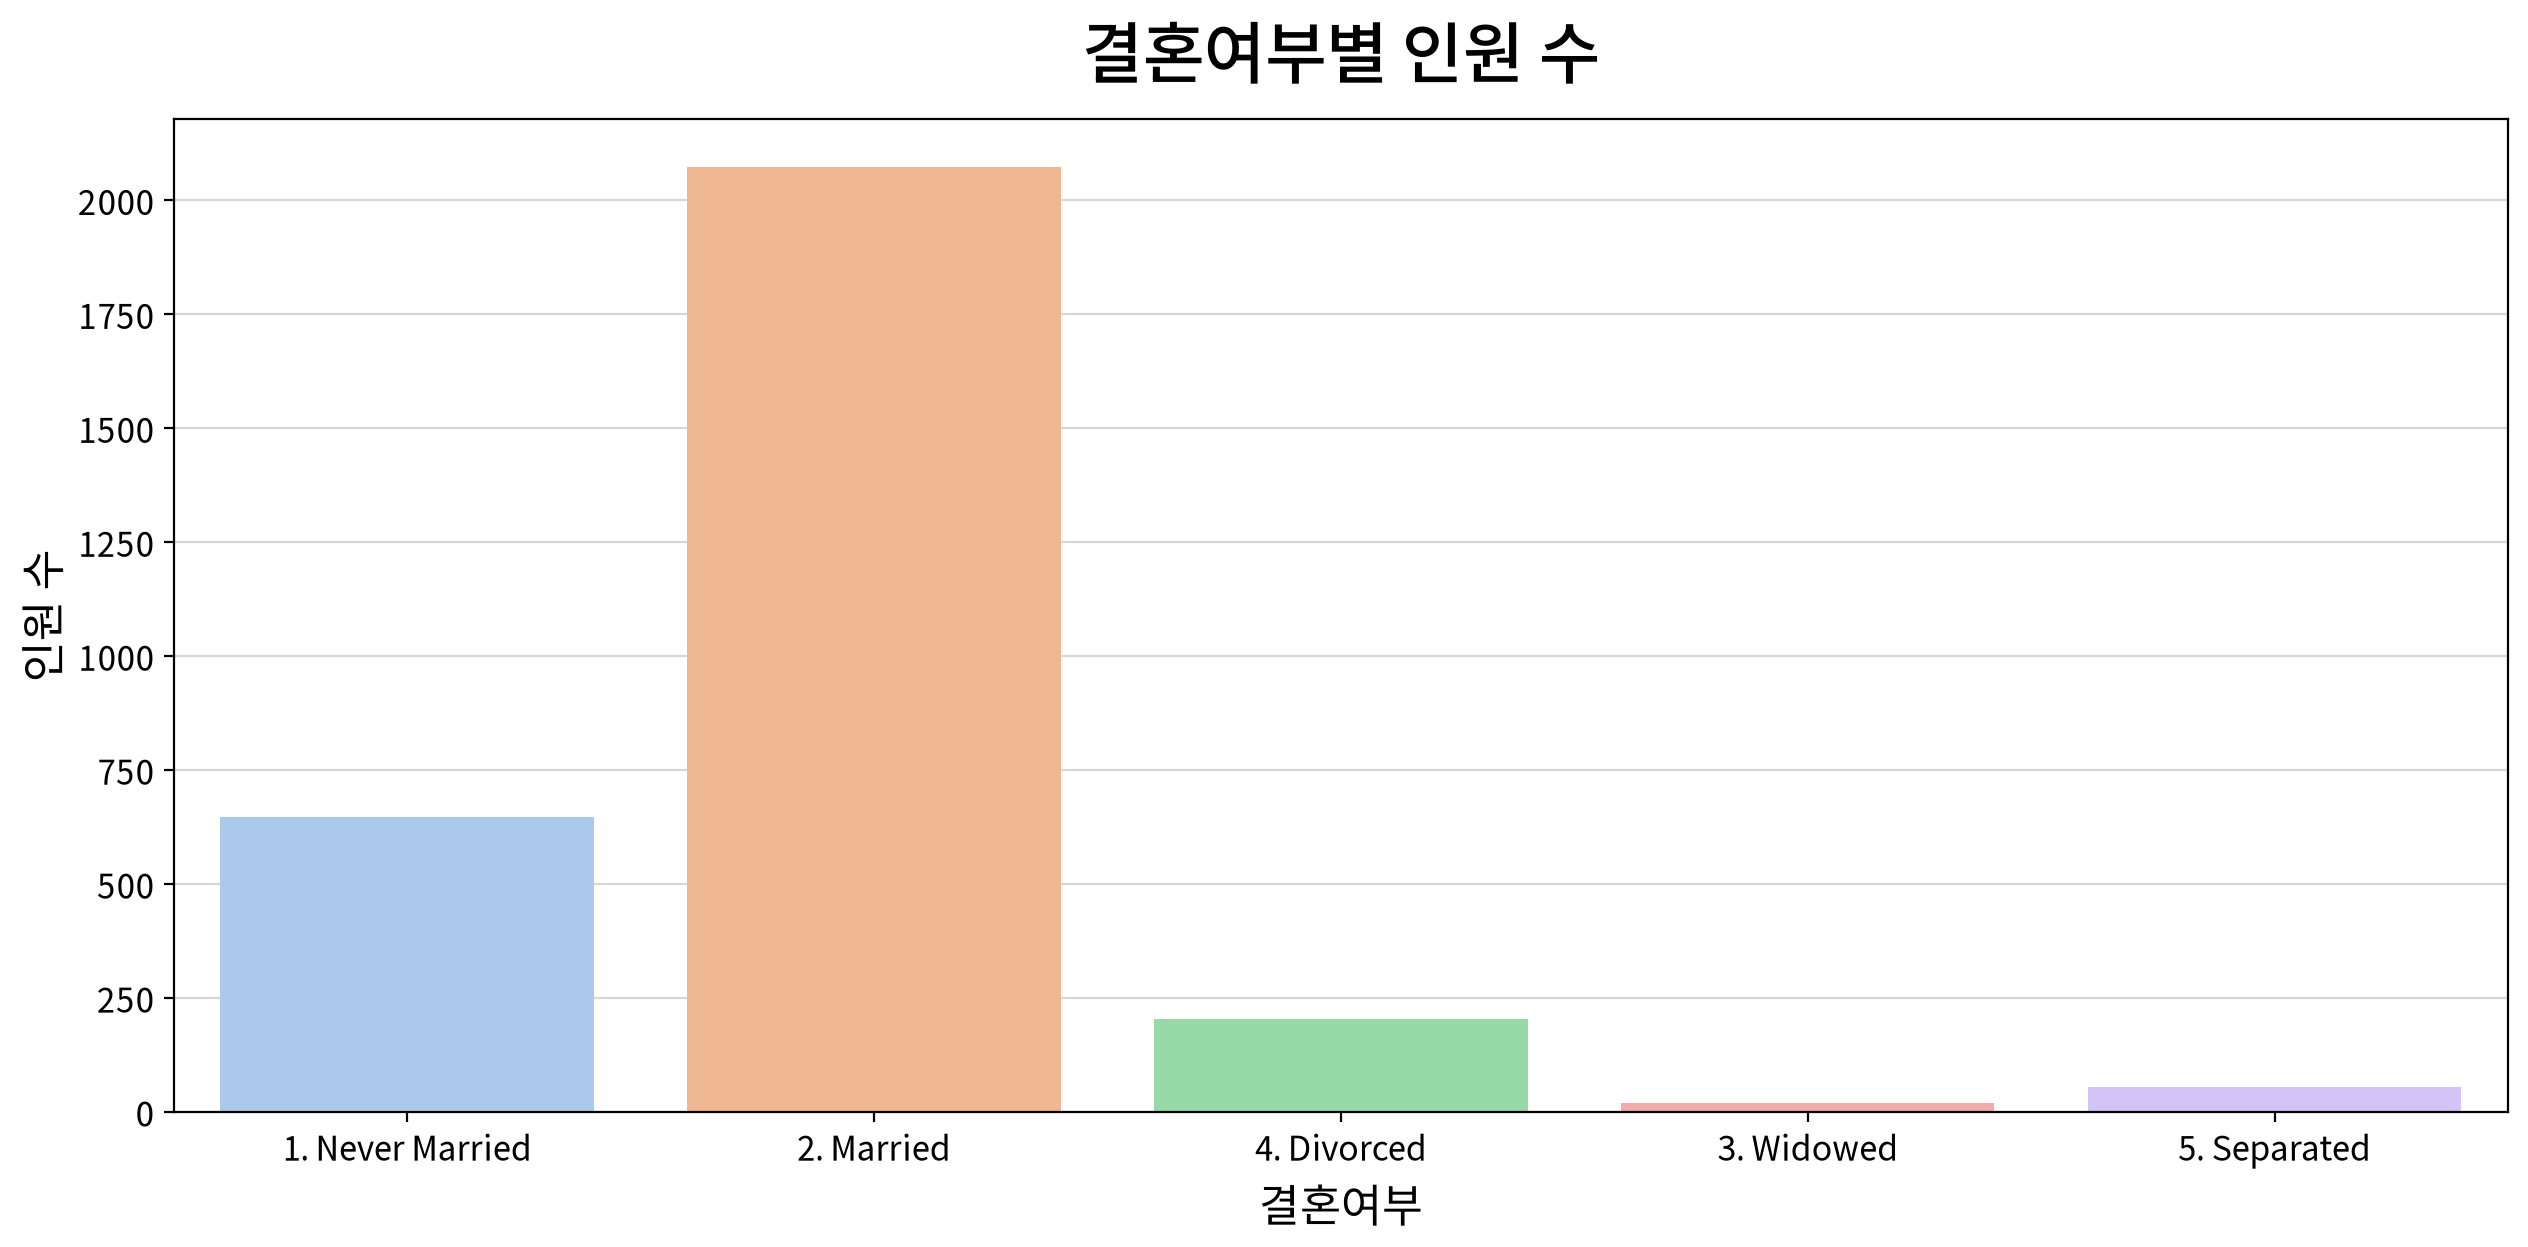

In [47]:
my_plot.countplot(origin, x="maritl", hue="maritl", palette="pastel",
                  title="결혼여부별 인원 수", xlabel="결혼여부", ylabel="인원 수")

## 문제 2. 임금(`wage`)의 분포 형태로 가장 적절한 설명은?

① 좌우 대칭  ② 오른쪽으로 꼬리가 긴(우편향) 분포  ③ 왼쪽으로 꼬리가 긴(좌편향) 분포  ④ 균등(평탄) 분포

> 💡 **힌트**: 히스토그램 또는 박스플롯
> 🎯 **ADsP 개념**: 분포의 형태 · 왜도(skewness) · 평균과 중앙값의 관계

In [48]:
print("평균:", origin["wage"].mean(), "| 중앙값:", origin["wage"].median())

평균: 111.70360820174345 | 중앙값: 104.9215065336639


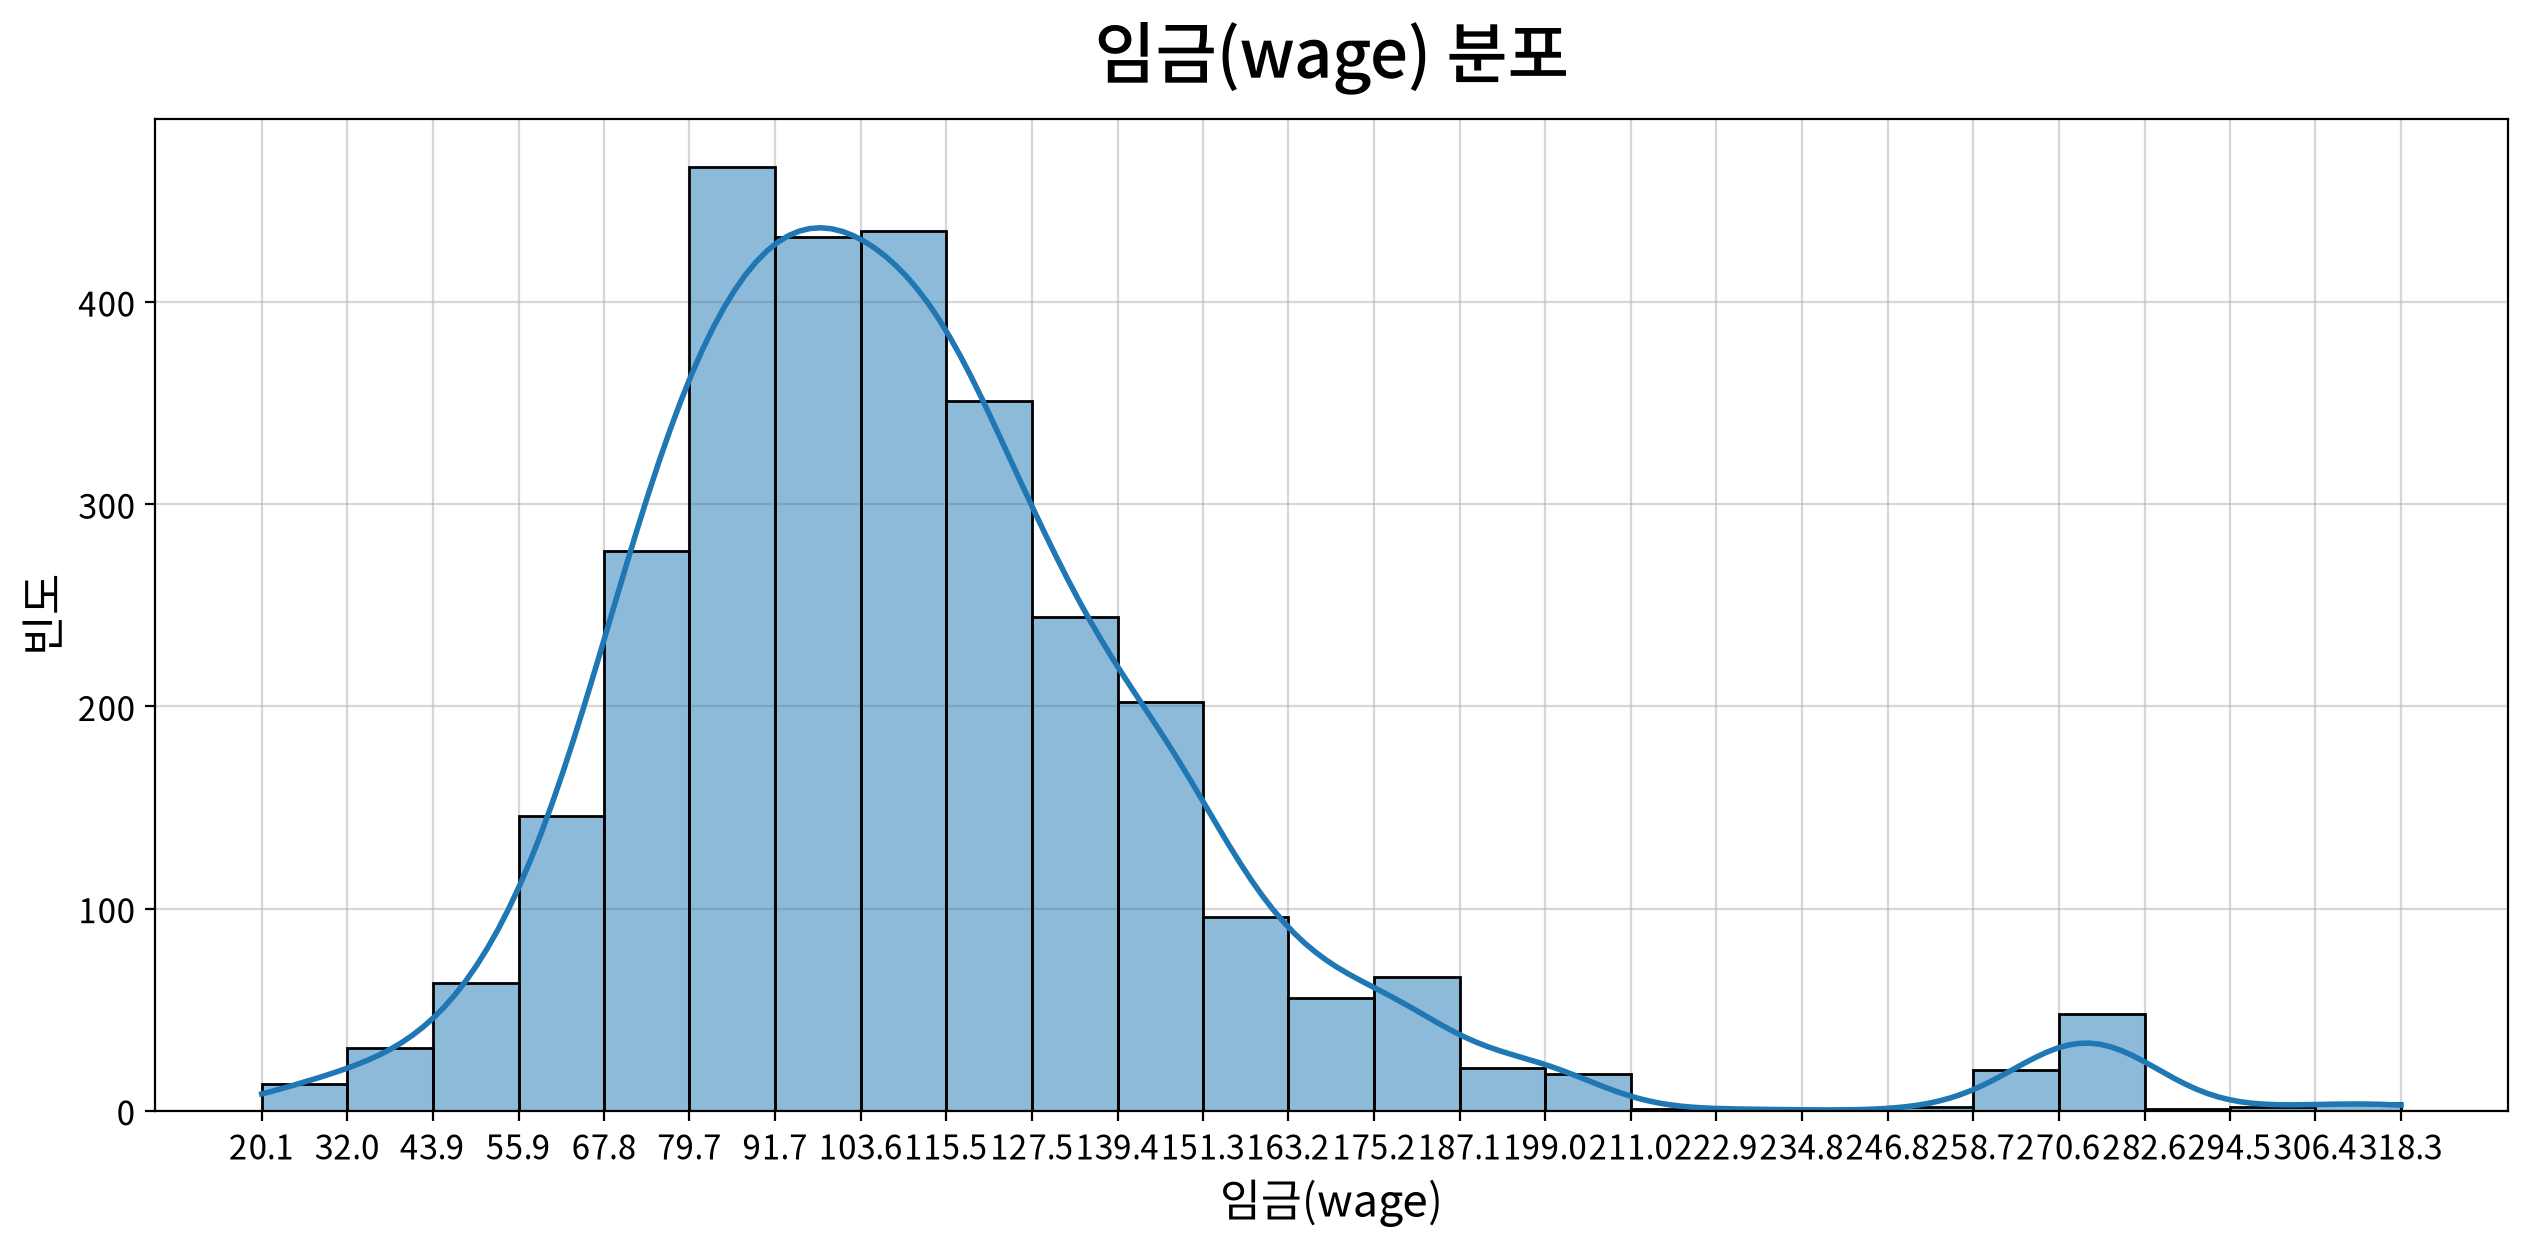

In [49]:
my_plot.histplot(origin, x="wage", bins=25, kde=True,
                 title="임금(wage) 분포", xlabel="임금(wage)", ylabel="빈도")

## 문제 3. 나이(`age`)의 중앙값(median)에 가장 가까운 값은?

① 34  ② 42  ③ 51  ④ 60

> 💡 **힌트**: 박스플롯 또는 히스토그램
> 🎯 **ADsP 개념**: 대푯값(중앙값) · 사분위수

In [50]:
origin["age"].describe()

count   3000.000
mean      42.415
std       11.542
min       18.000
25%       33.750
50%       42.000
75%       51.000
max       80.000
Name: age, dtype: float64

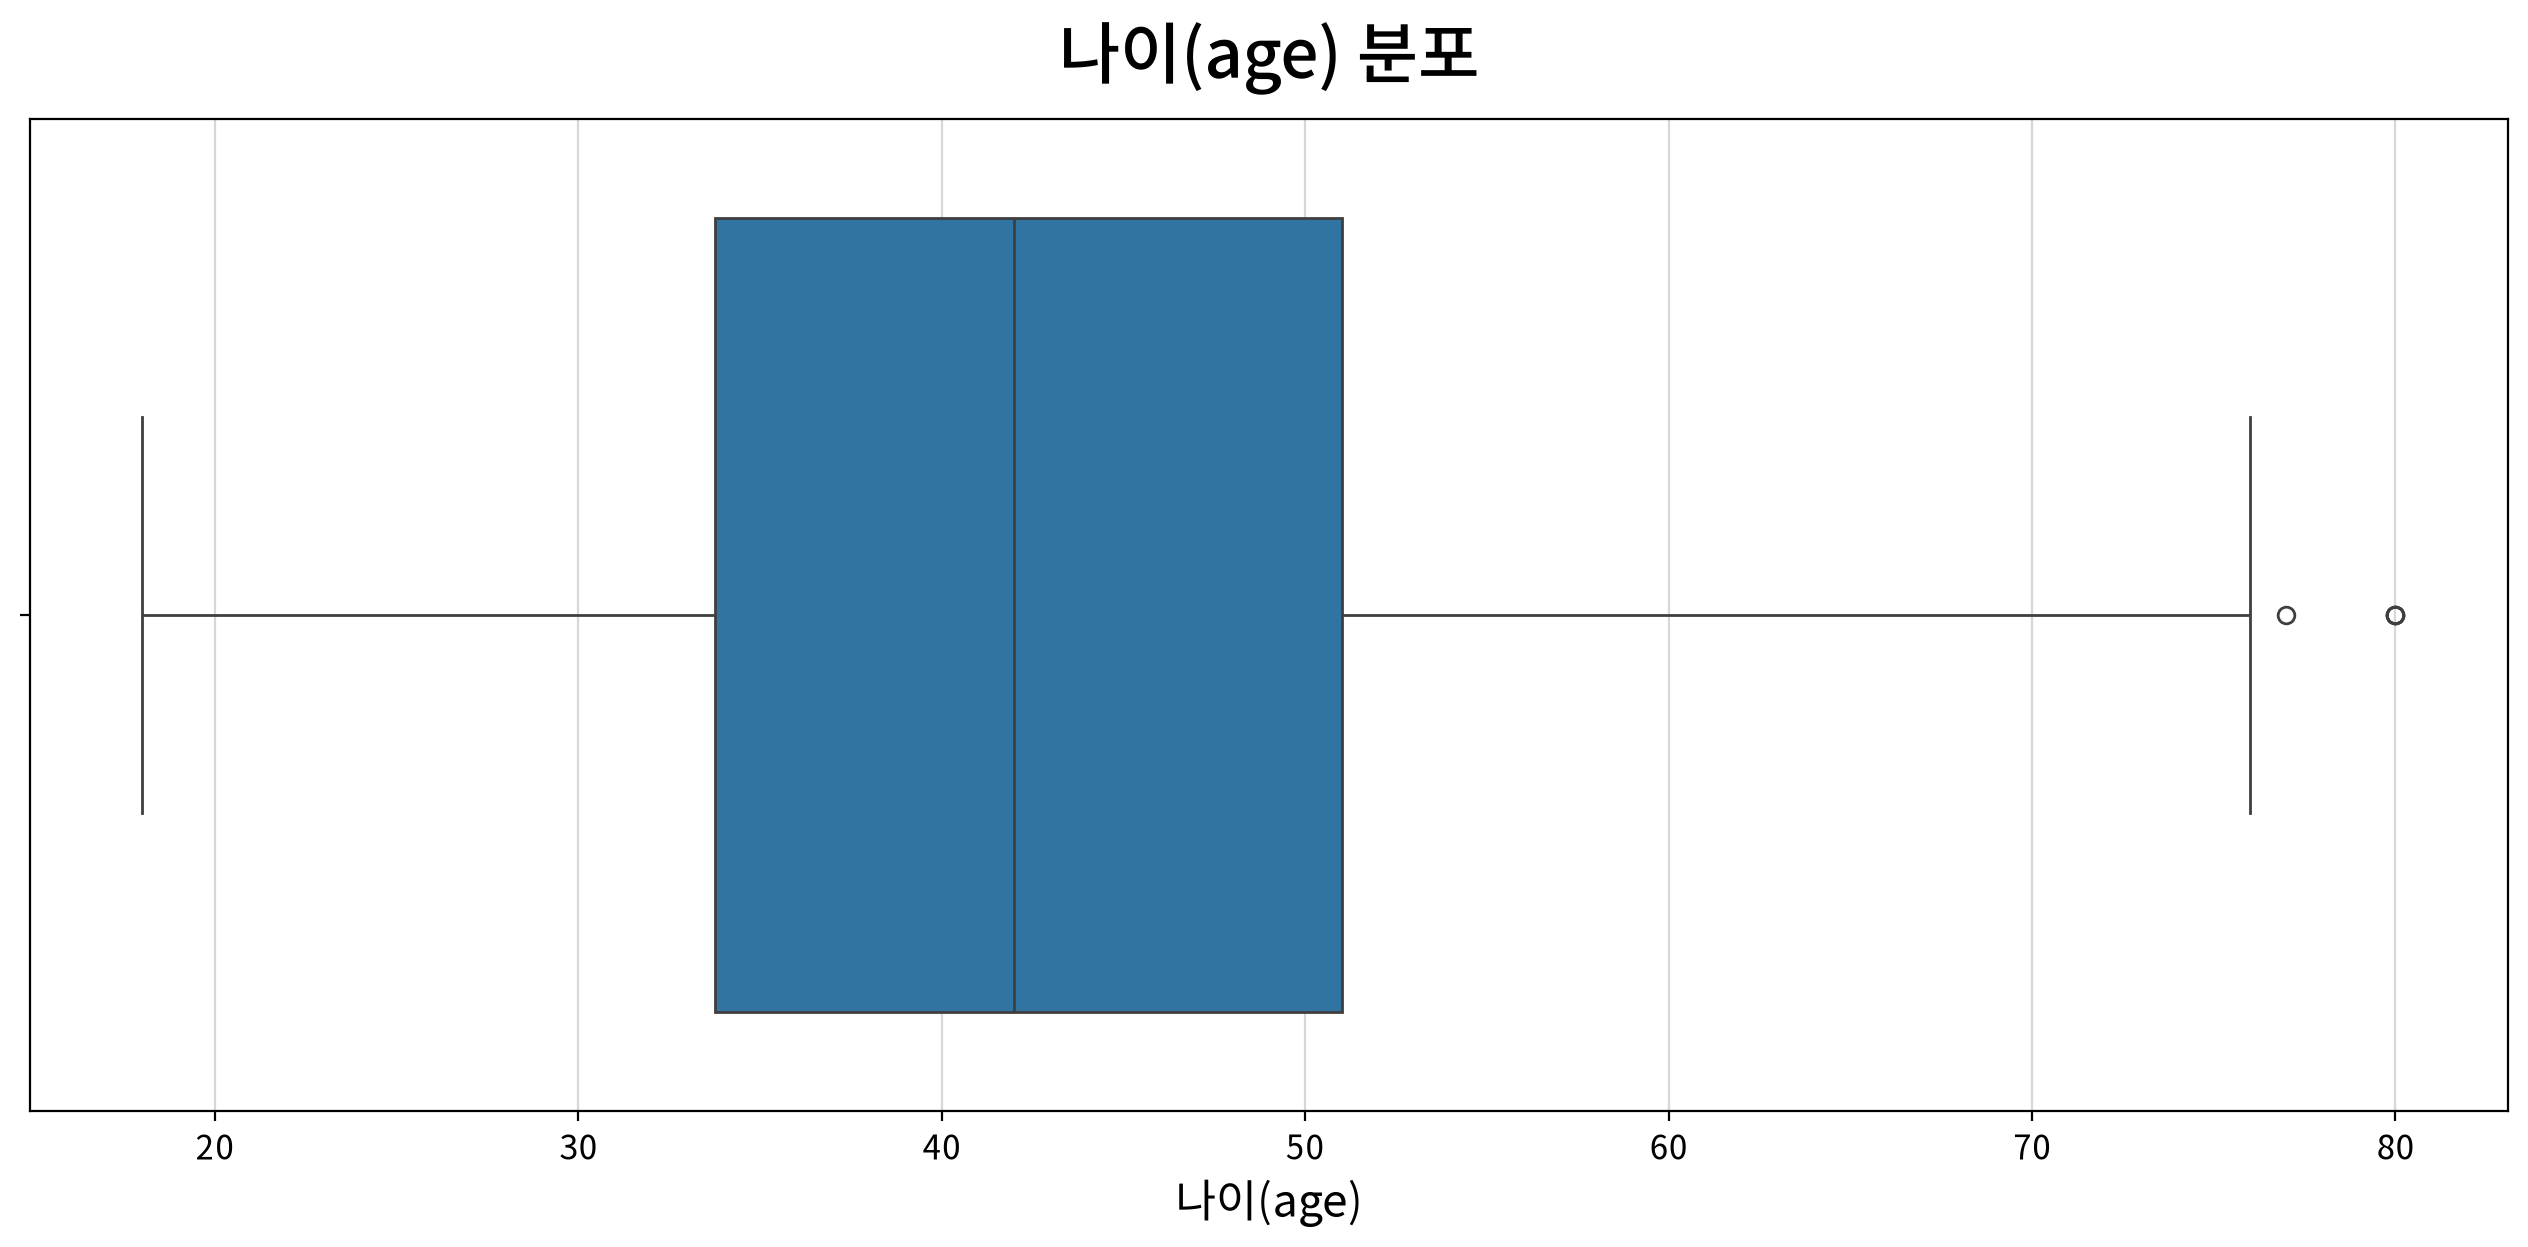

In [51]:
my_plot.boxplot(origin, x="age", title="나이(age) 분포", xlabel="나이(age)")

## 문제 4. `age`, `wage`, `logwage` 세 변수 중, 상단에 이상치(극단적으로 큰 값)가 가장 두드러지게 나타나는 변수는?

① age  ② wage  ③ logwage  ④ 모두 동일하다

> 💡 **힌트**: 박스플롯 (세 변수를 개별적으로)
> 🎯 **ADsP 개념**: 이상치(outlier) 탐지 · 상자그림(IQR 기준)

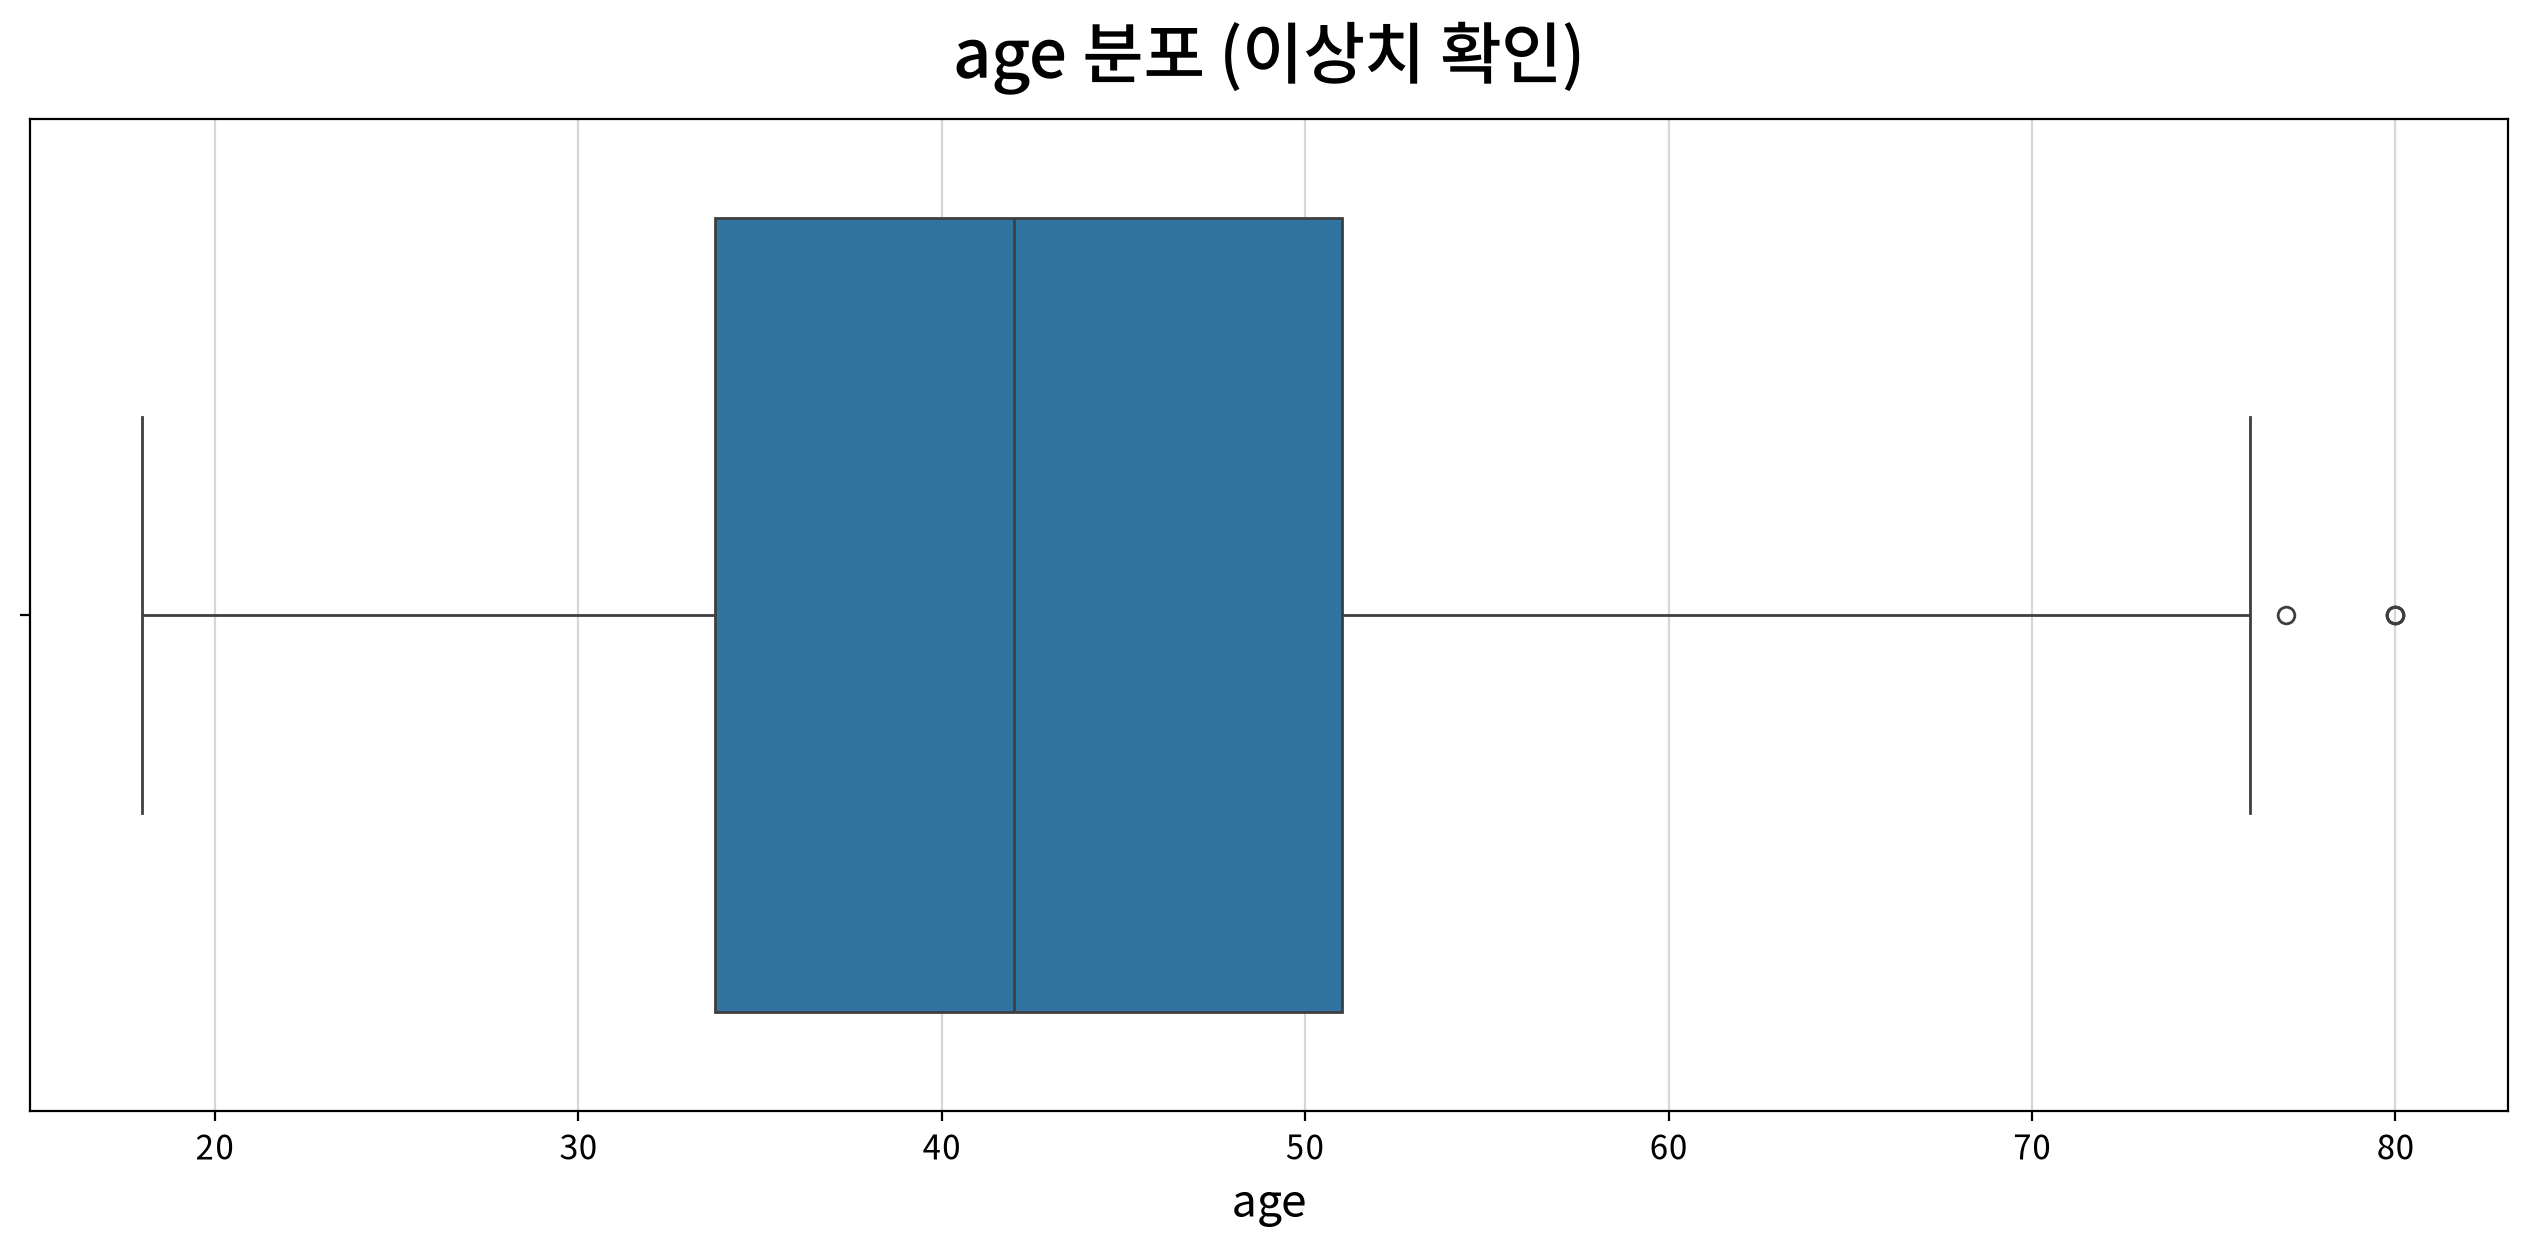

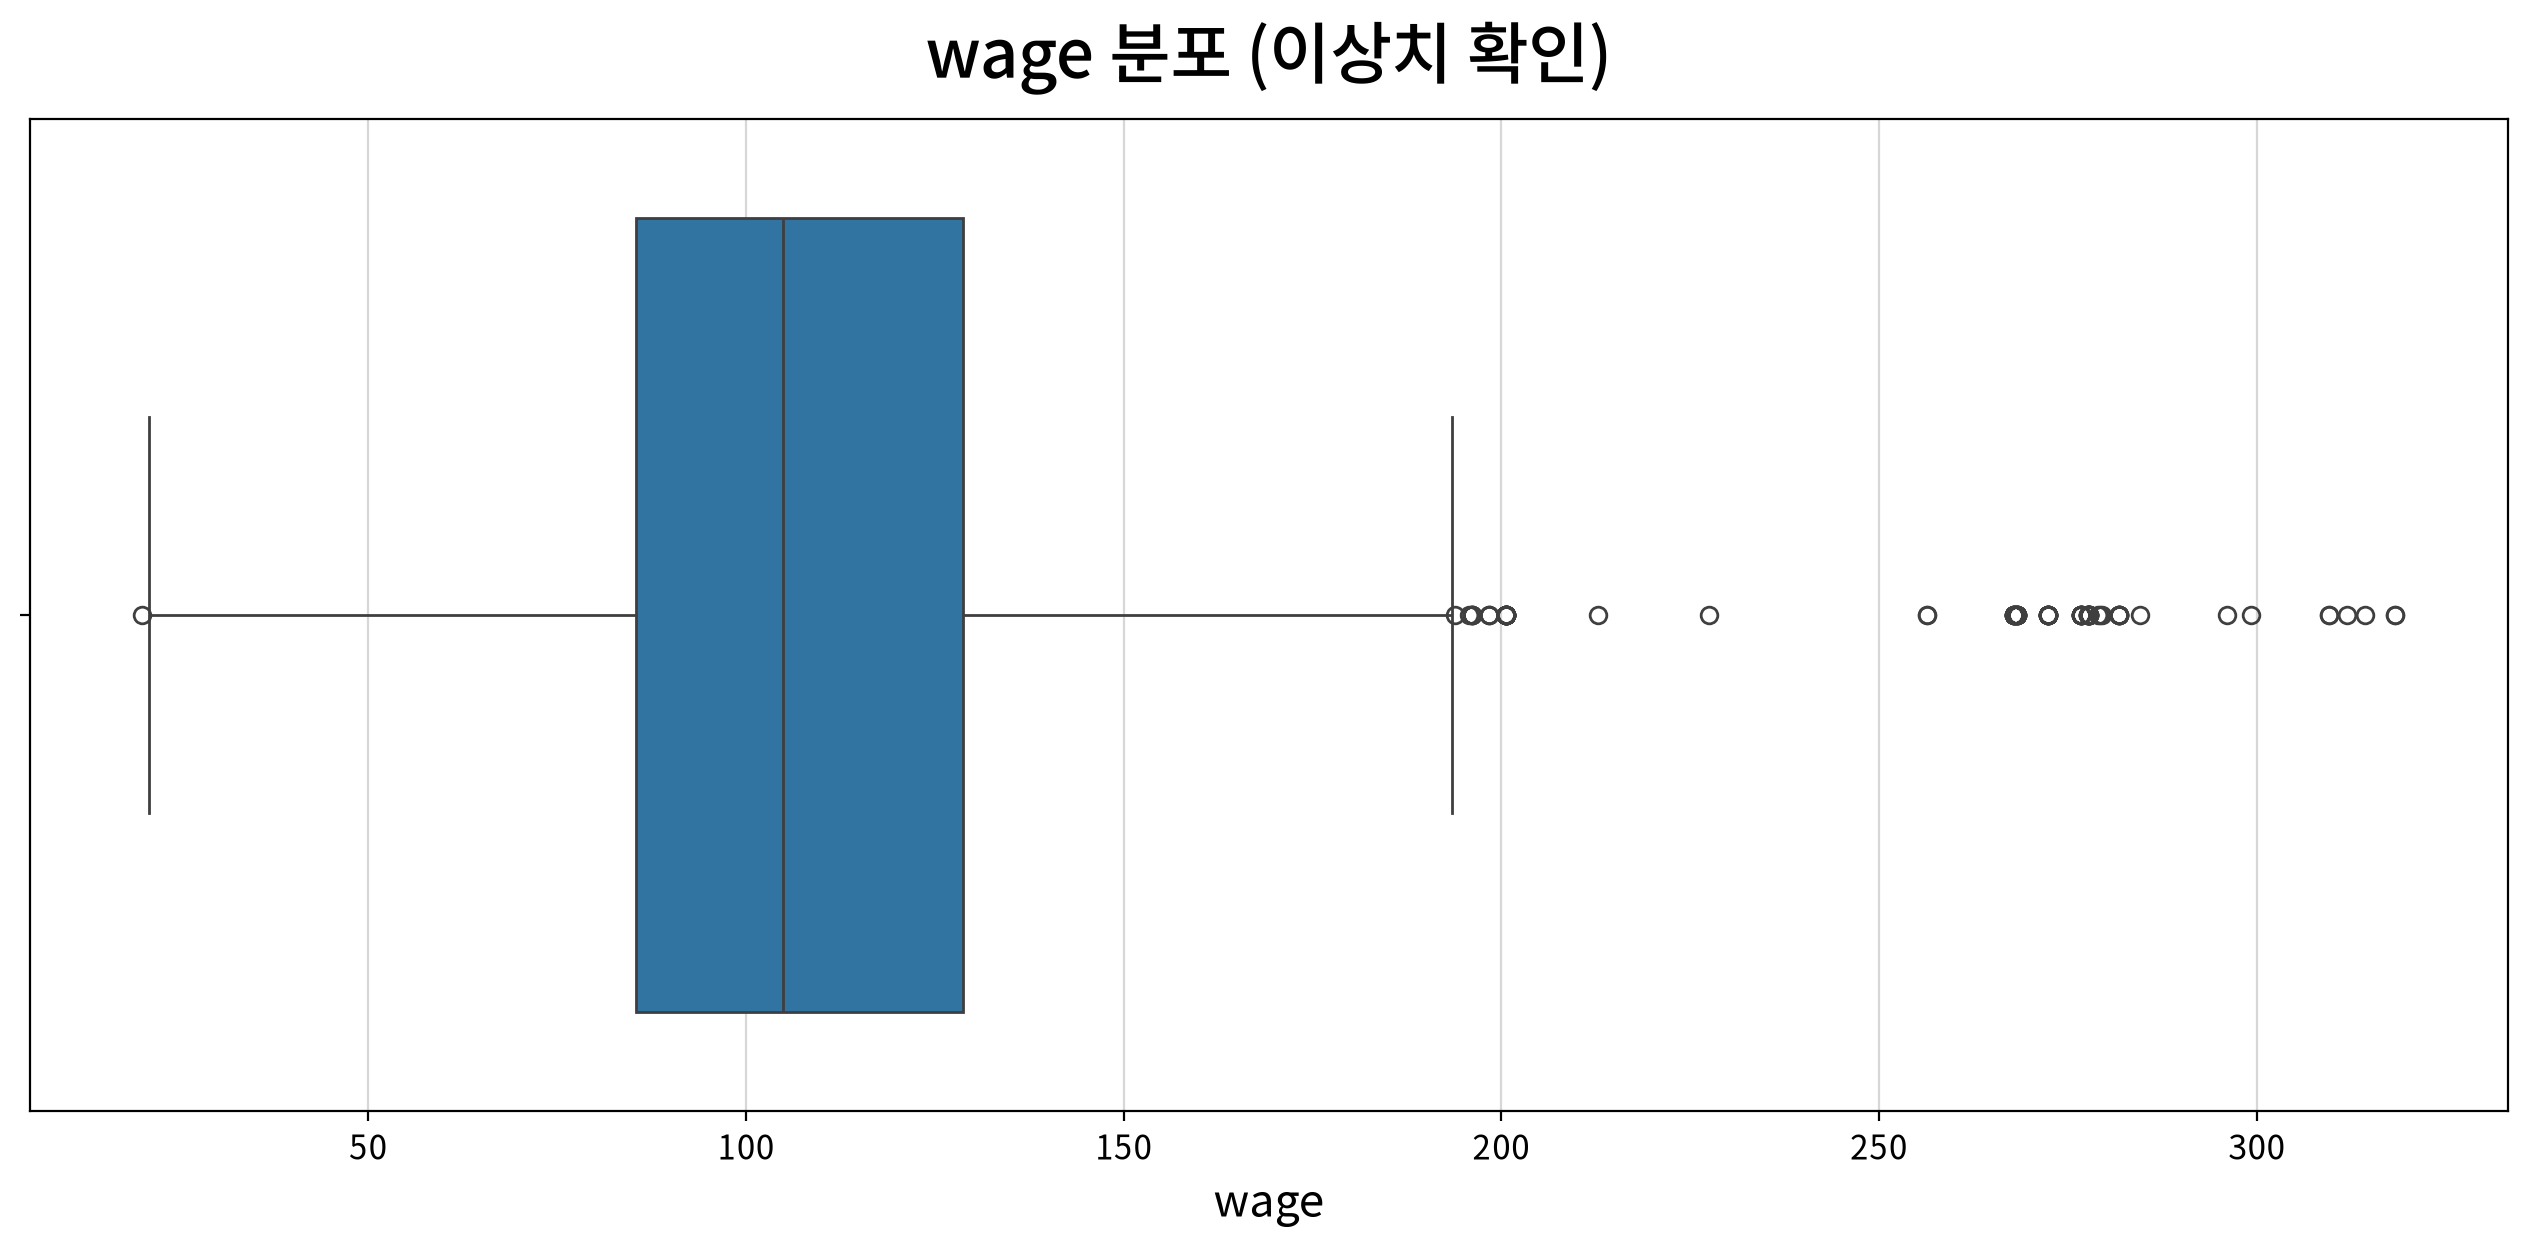

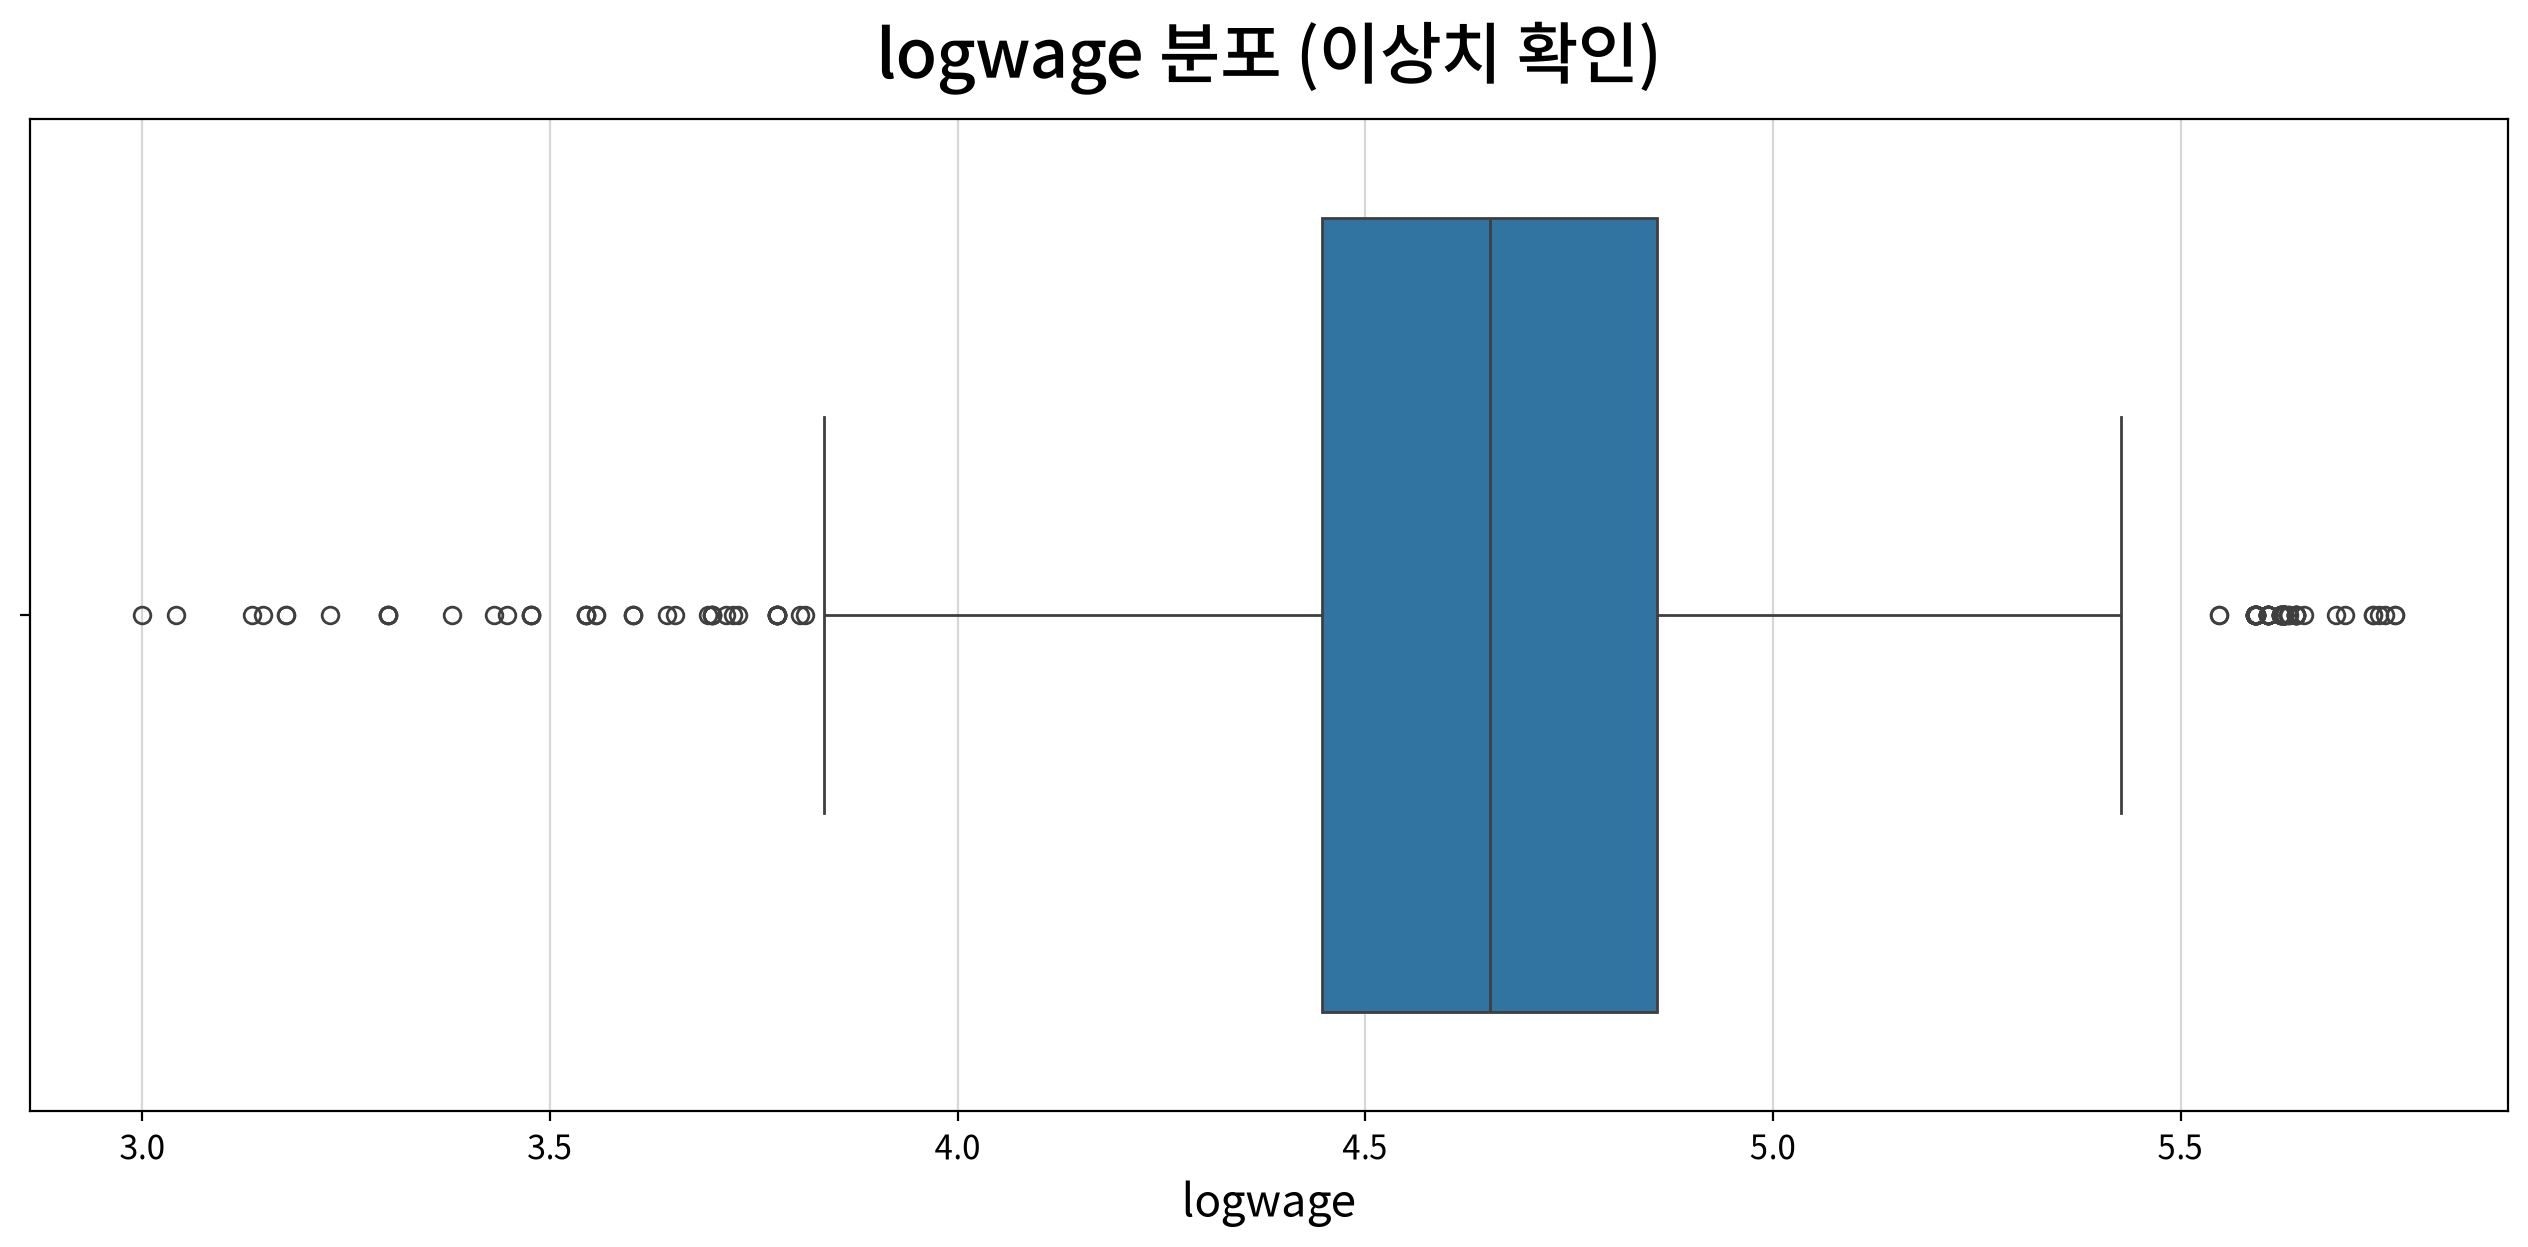

In [52]:
for c in ["age", "wage", "logwage"]:
    my_plot.boxplot(origin, x=c, title=f"{c} 분포 (이상치 확인)", xlabel=c)

## 문제 5. `wage`와 `logwage` 중, 분포가 더 좌우 대칭에 가까운 변수는?

① wage  ② logwage  ③ 둘이 완전히 동일  ④ 판단할 수 없음

> 💡 **힌트**: 히스토그램 또는 박스플롯 (두 변수 비교)
> 🎯 **ADsP 개념**: 변수 변환(로그 변환) · 분포의 정규성

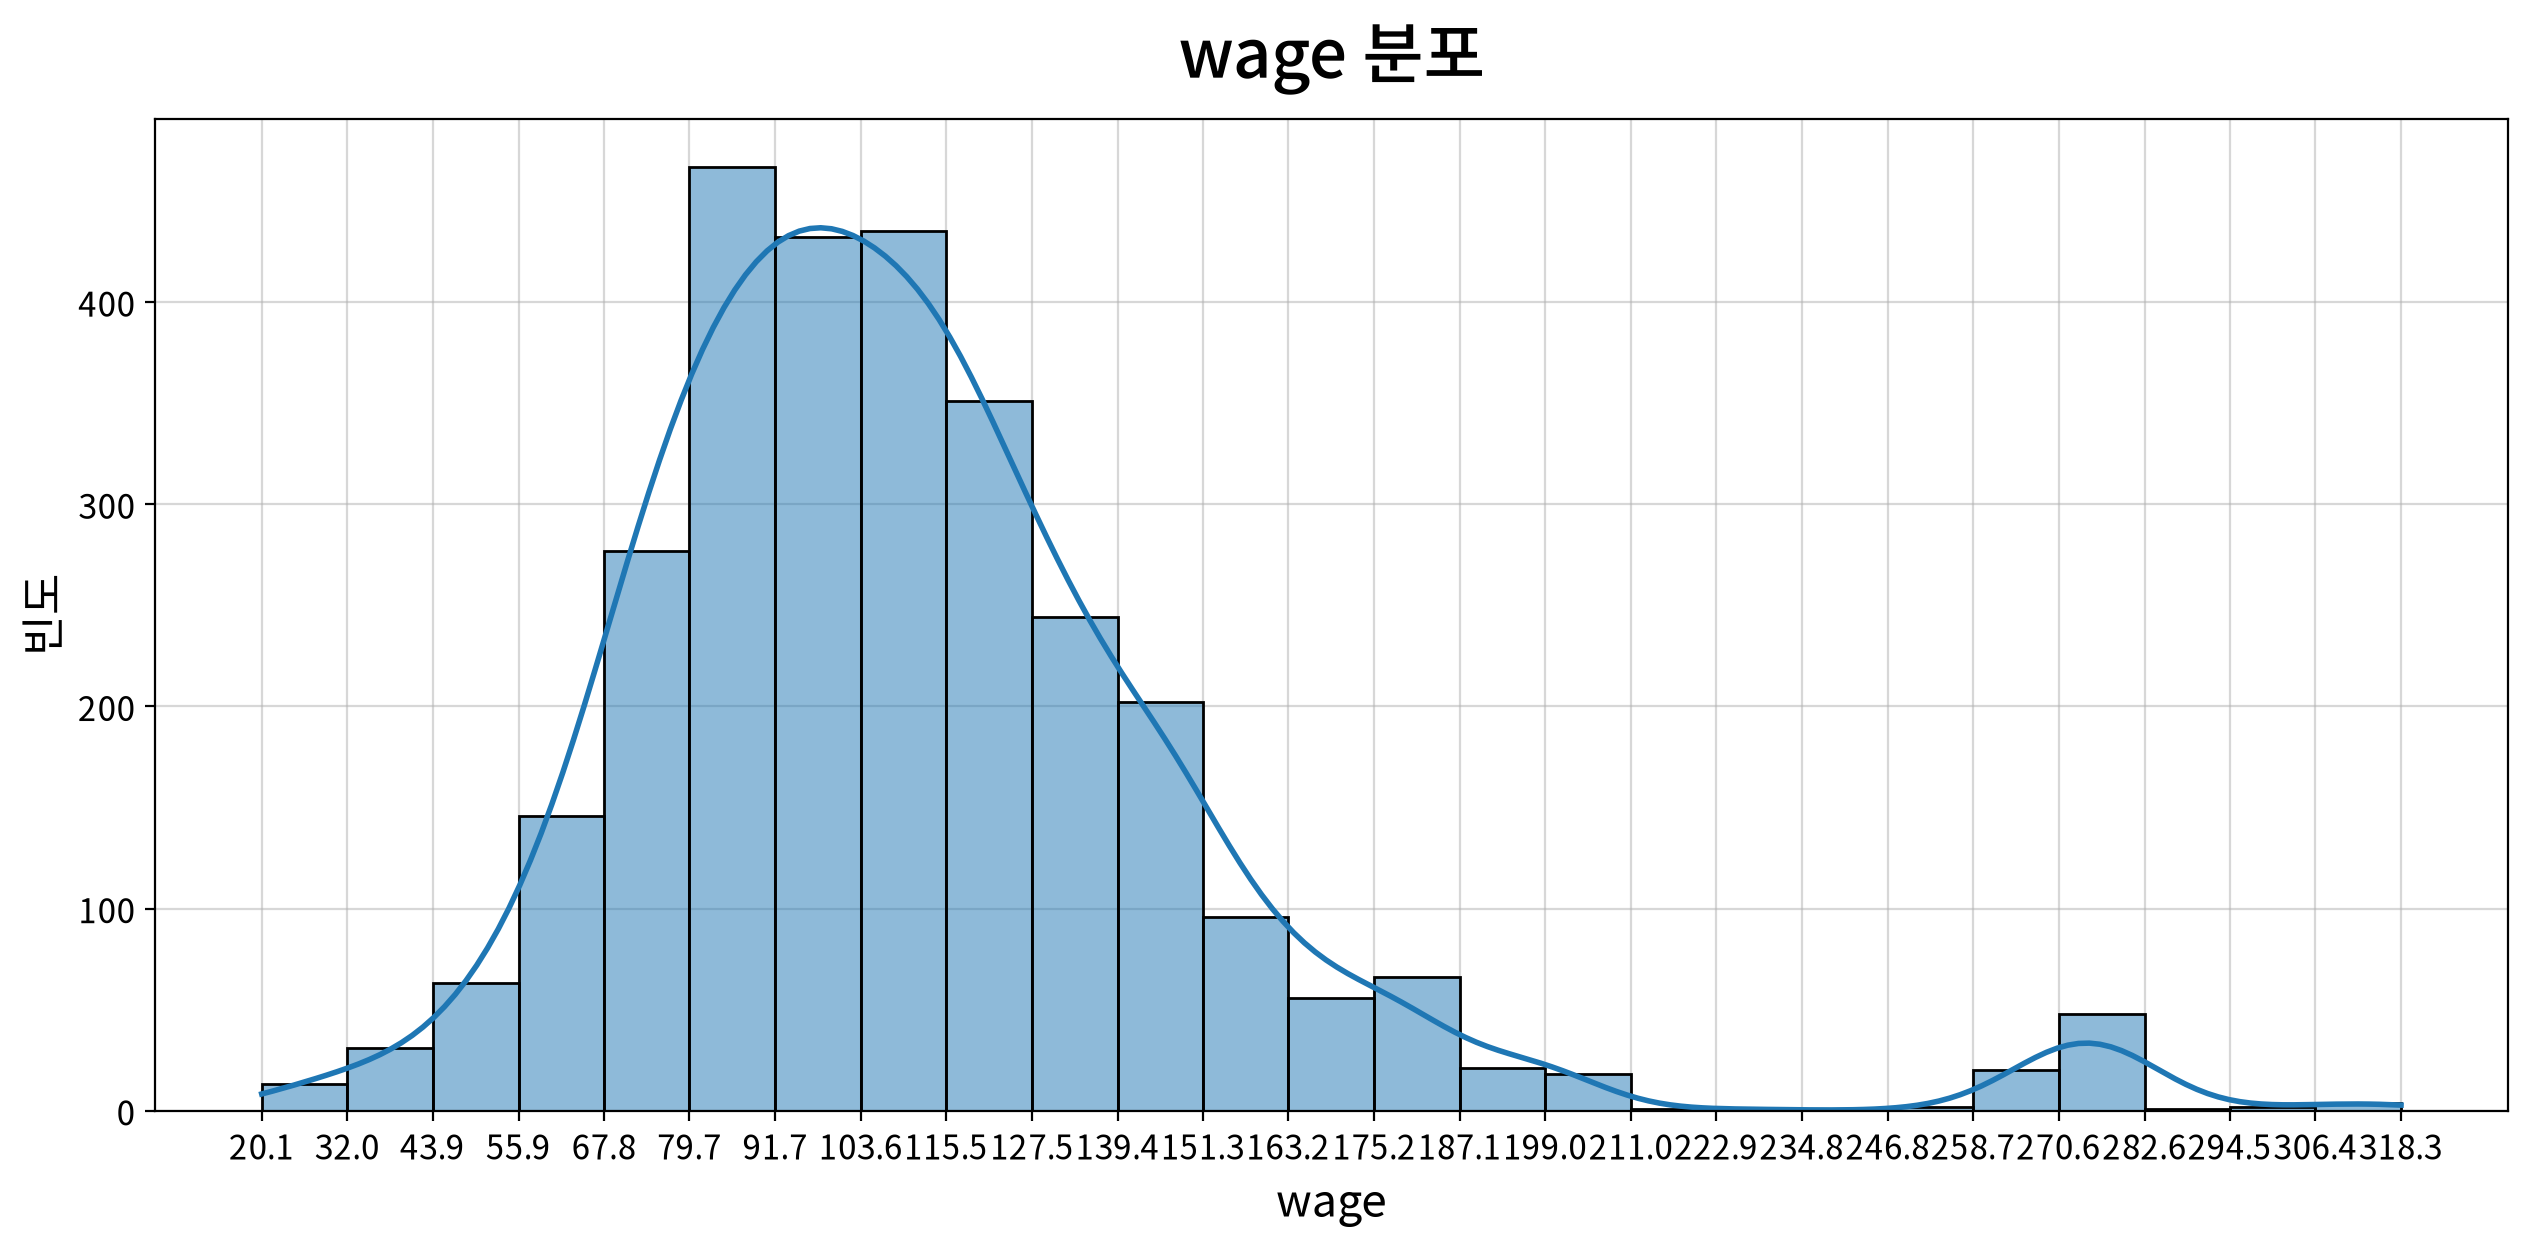

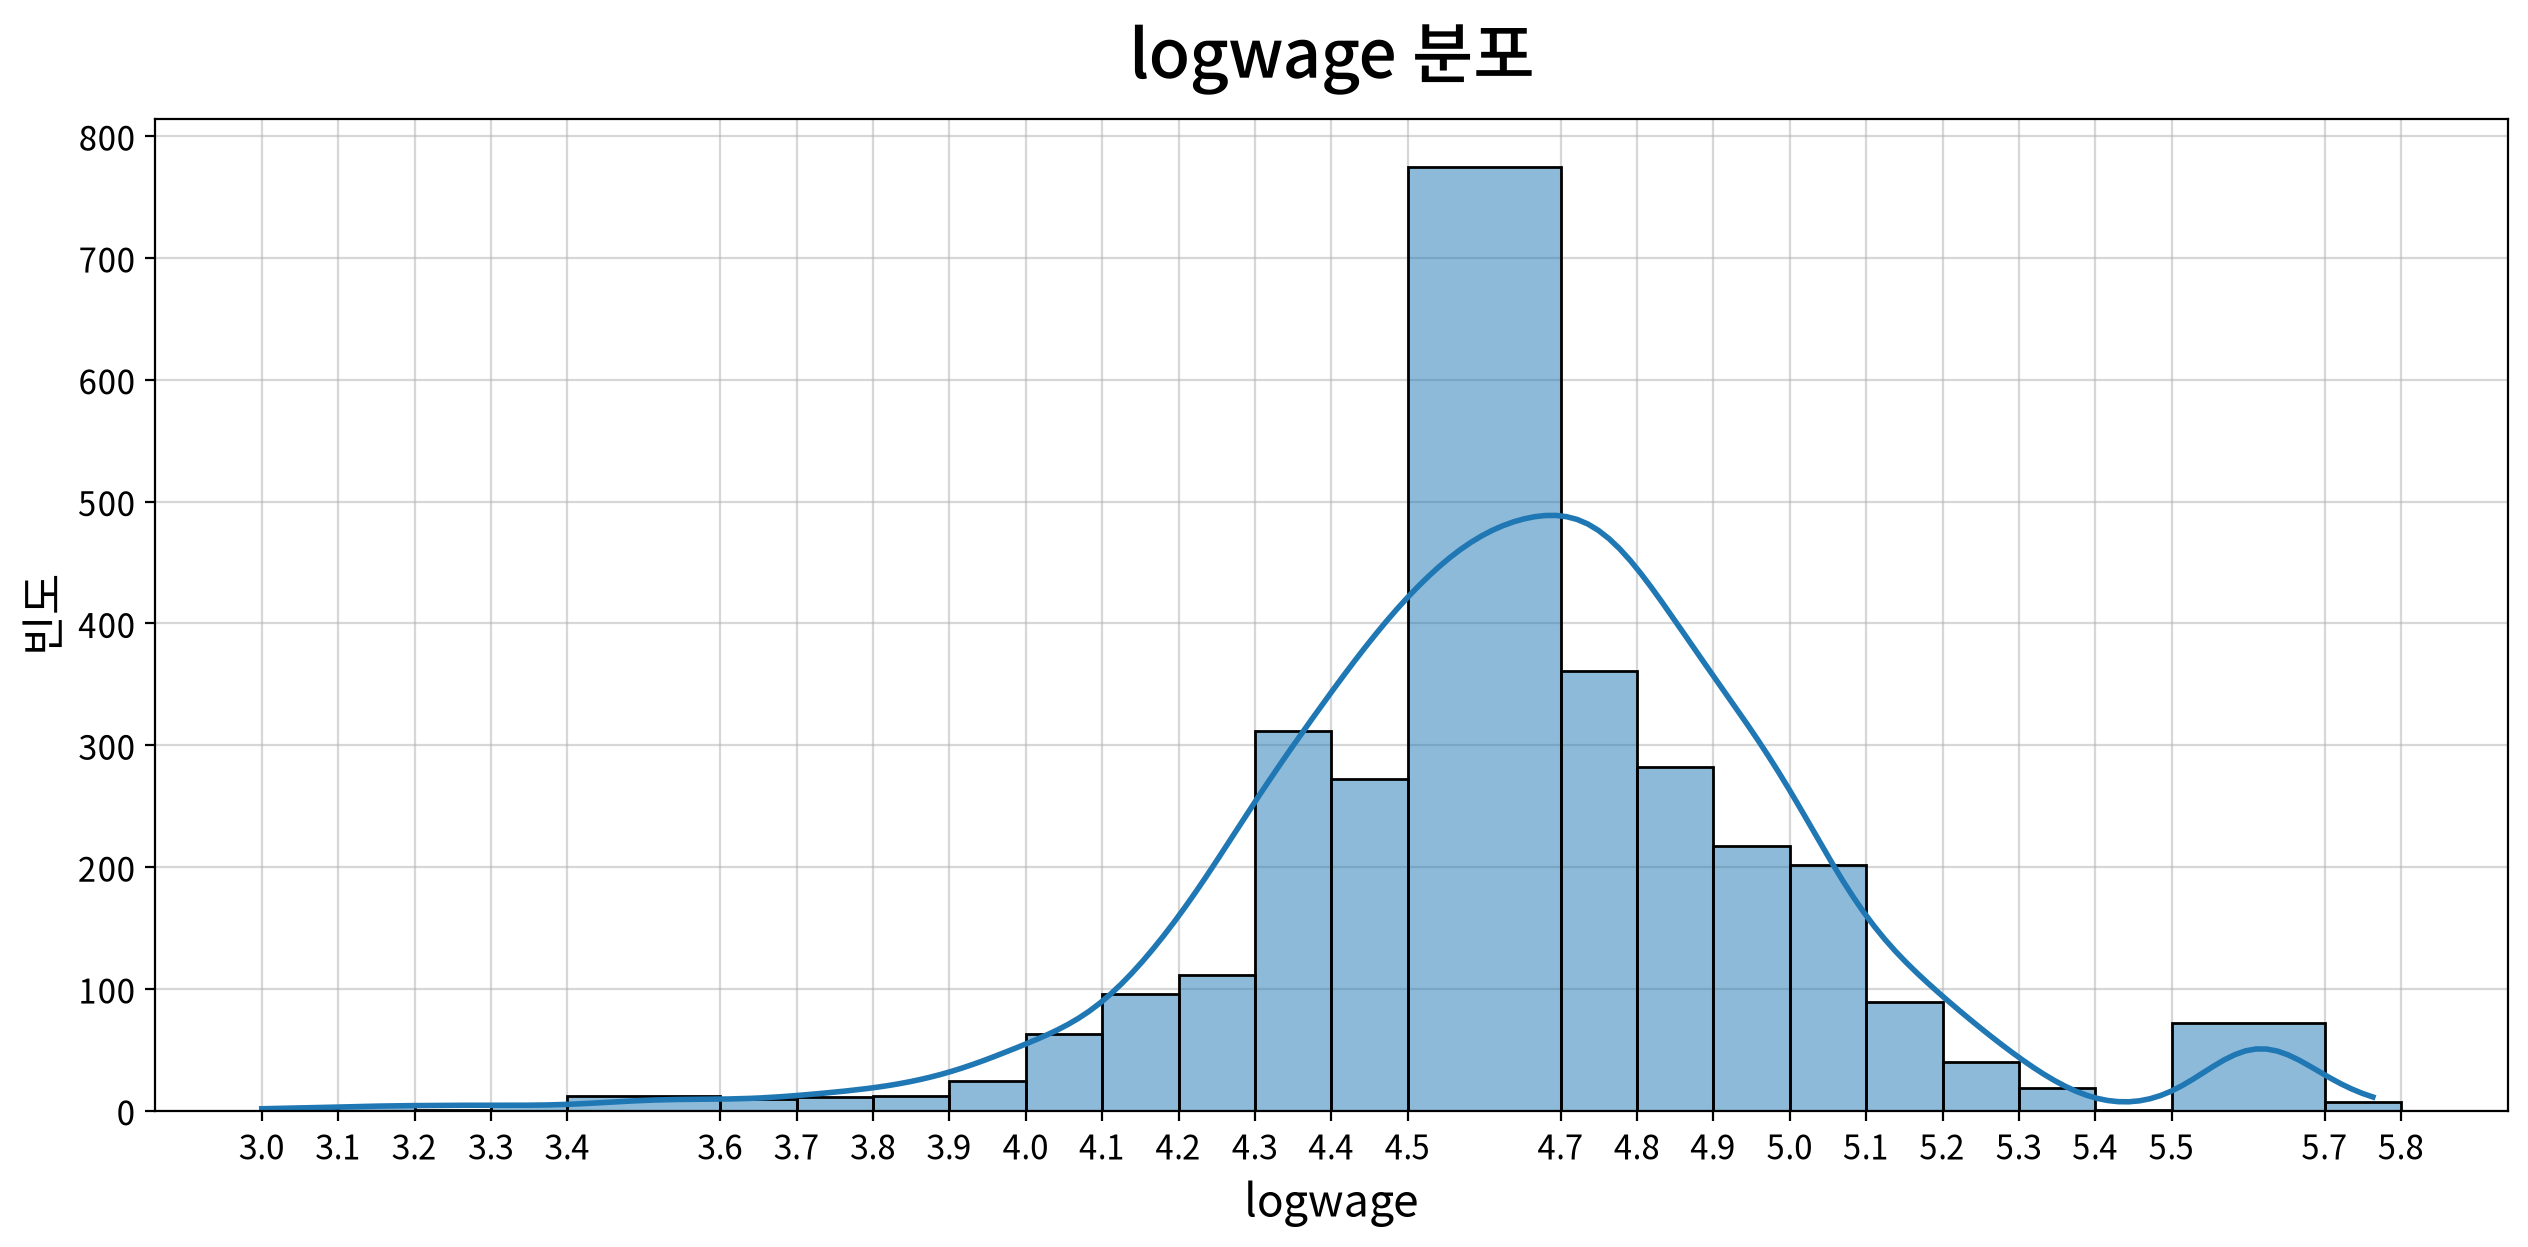

In [53]:
for c in ["wage", "logwage"]:
    my_plot.histplot(origin, x=c, bins=25, kde=True,
                     title=f"{c} 분포", xlabel=c, ylabel="빈도")

## 문제 6. 교육 수준(`education`)과 임금(`wage`)의 관계로 옳은 것은?

① 교육 수준이 높을수록 임금이 높다  ② 교육 수준이 높을수록 임금이 낮다  ③ 관계가 없다  ④ 고졸에서 임금이 가장 높다

> 💡 **힌트**: 막대그래프 또는 박스플롯(교육수준별 wage)
> 🎯 **ADsP 개념**: 범주별 집단 비교 · 순서형 변수와 연속형의 관계

In [54]:
edu_order = sorted(origin["education"].unique())
edu_order

['1. < HS Grad',
 '2. HS Grad',
 '3. Some College',
 '4. College Grad',
 '5. Advanced Degree']

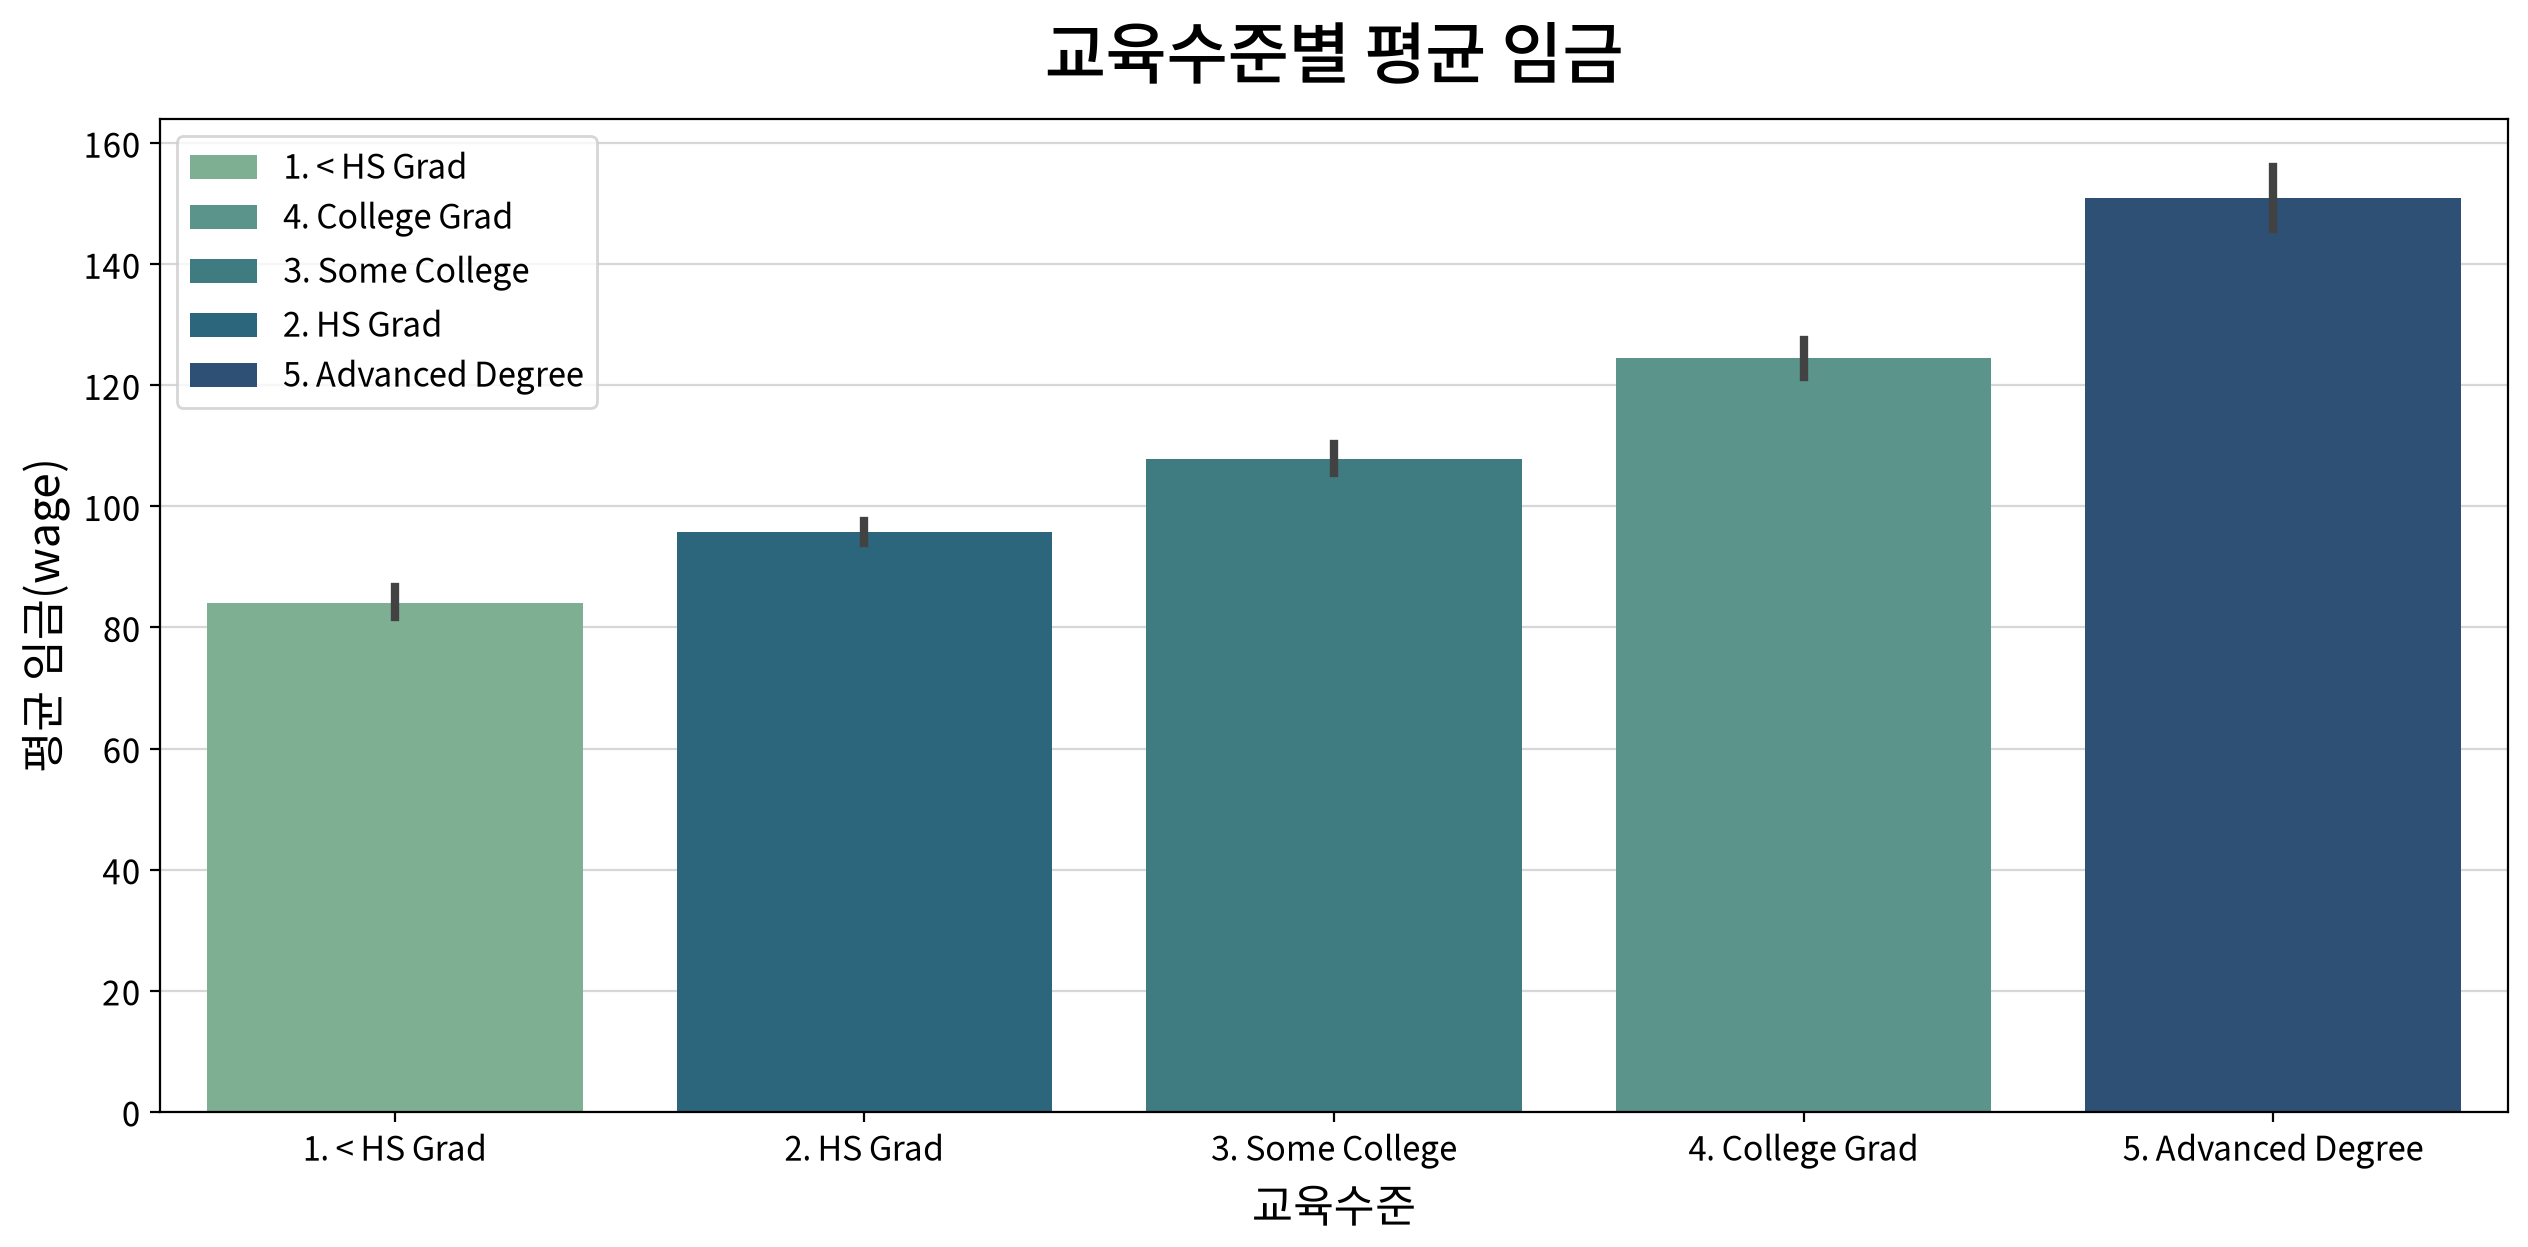

In [55]:
my_plot.barplot(origin, x="education", y="wage", estimator=np.mean,
                order=edu_order, hue="education", palette="crest",
                title="교육수준별 평균 임금", xlabel="교육수준", ylabel="평균 임금(wage)")

## 문제 7. 직군(`jobclass`)에 따른 임금 비교로 옳은 것은?

① 생산직(Industrial)이 더 높다  ② 사무직(Information)이 더 높다  ③ 차이가 없다  ④ 생산직이 2배 높다

> 💡 **힌트**: 박스플롯 / 바이올린플롯 / 막대그래프(직군별 wage)
> 🎯 **ADsP 개념**: 두 집단의 중심·분포 비교

In [56]:
origin.groupby("jobclass")["wage"].mean()

jobclass
1. Industrial    103.321
2. Information   120.593
Name: wage, dtype: float64

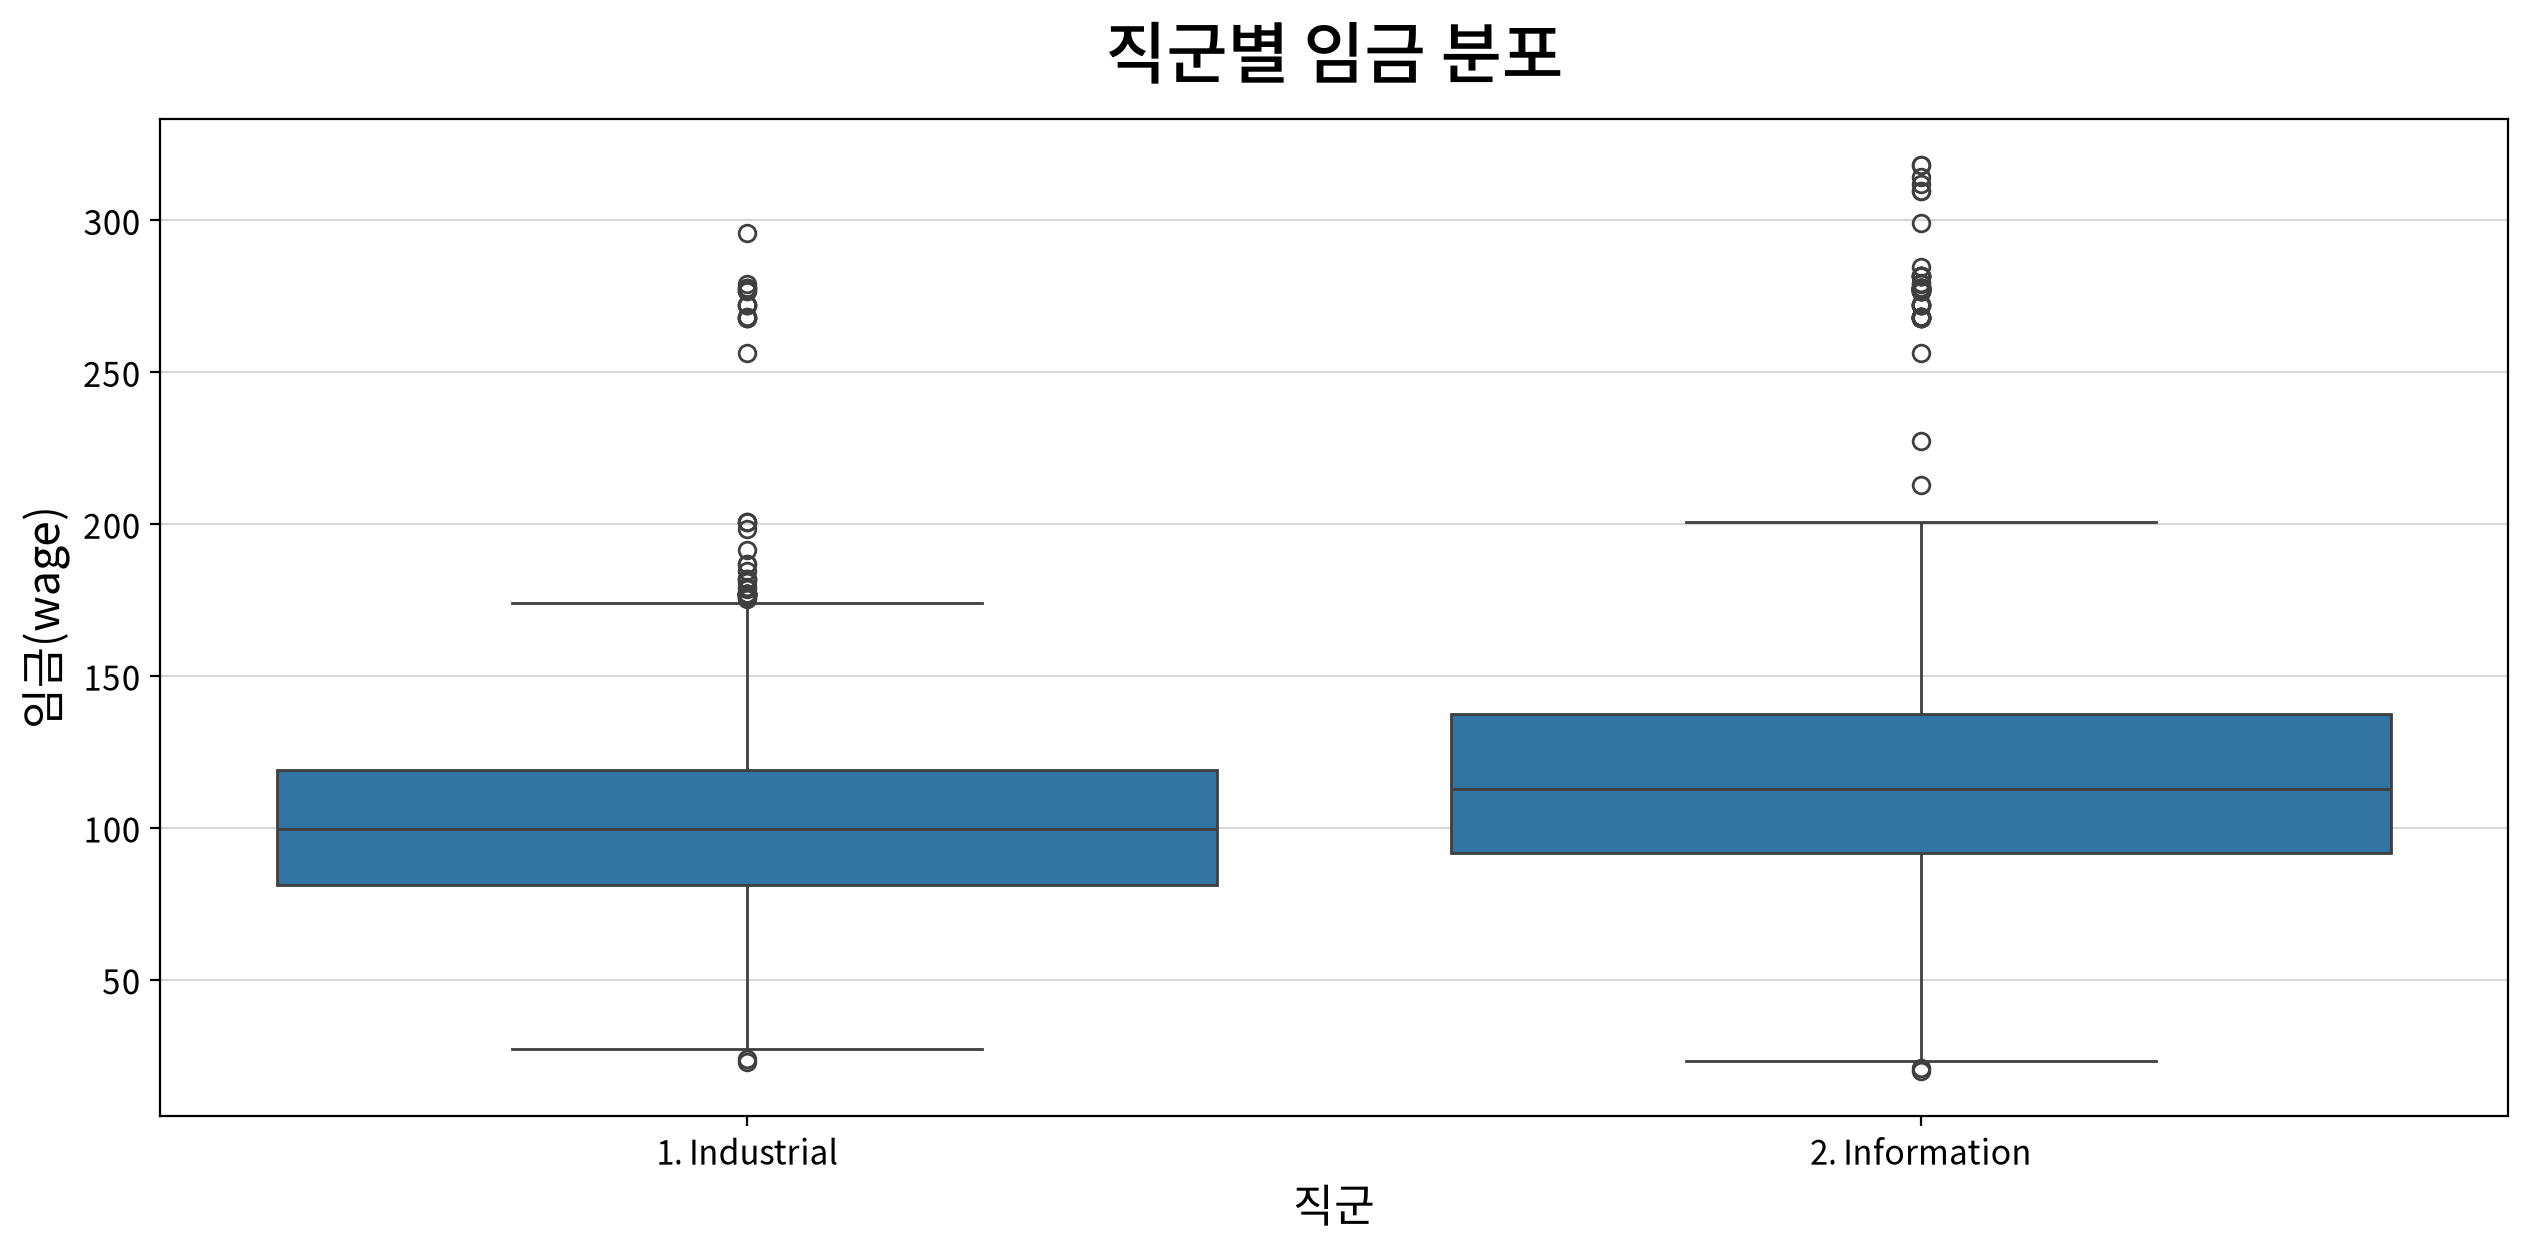

In [57]:
my_plot.boxplot(origin, x="jobclass", y="wage",
                title="직군별 임금 분포", xlabel="직군", ylabel="임금(wage)")

## 문제 8. 인종(`race`)별 평균 임금이 가장 높은 집단은?

① White  ② Black  ③ Asian  ④ Other

> 💡 **힌트**: 막대그래프 또는 박스플롯(인종별 wage)
> 🎯 **ADsP 개념**: 빈도(표본 수)와 평균(대푯값)의 구분

In [58]:
race_order = sorted(origin["race"].unique())
race_mean = origin.groupby("race")["wage"].mean().sort_values(ascending=False)
race_mean

race
3. Asian   120.288
1. White   112.564
2. Black   101.601
4. Other    89.973
Name: wage, dtype: float64

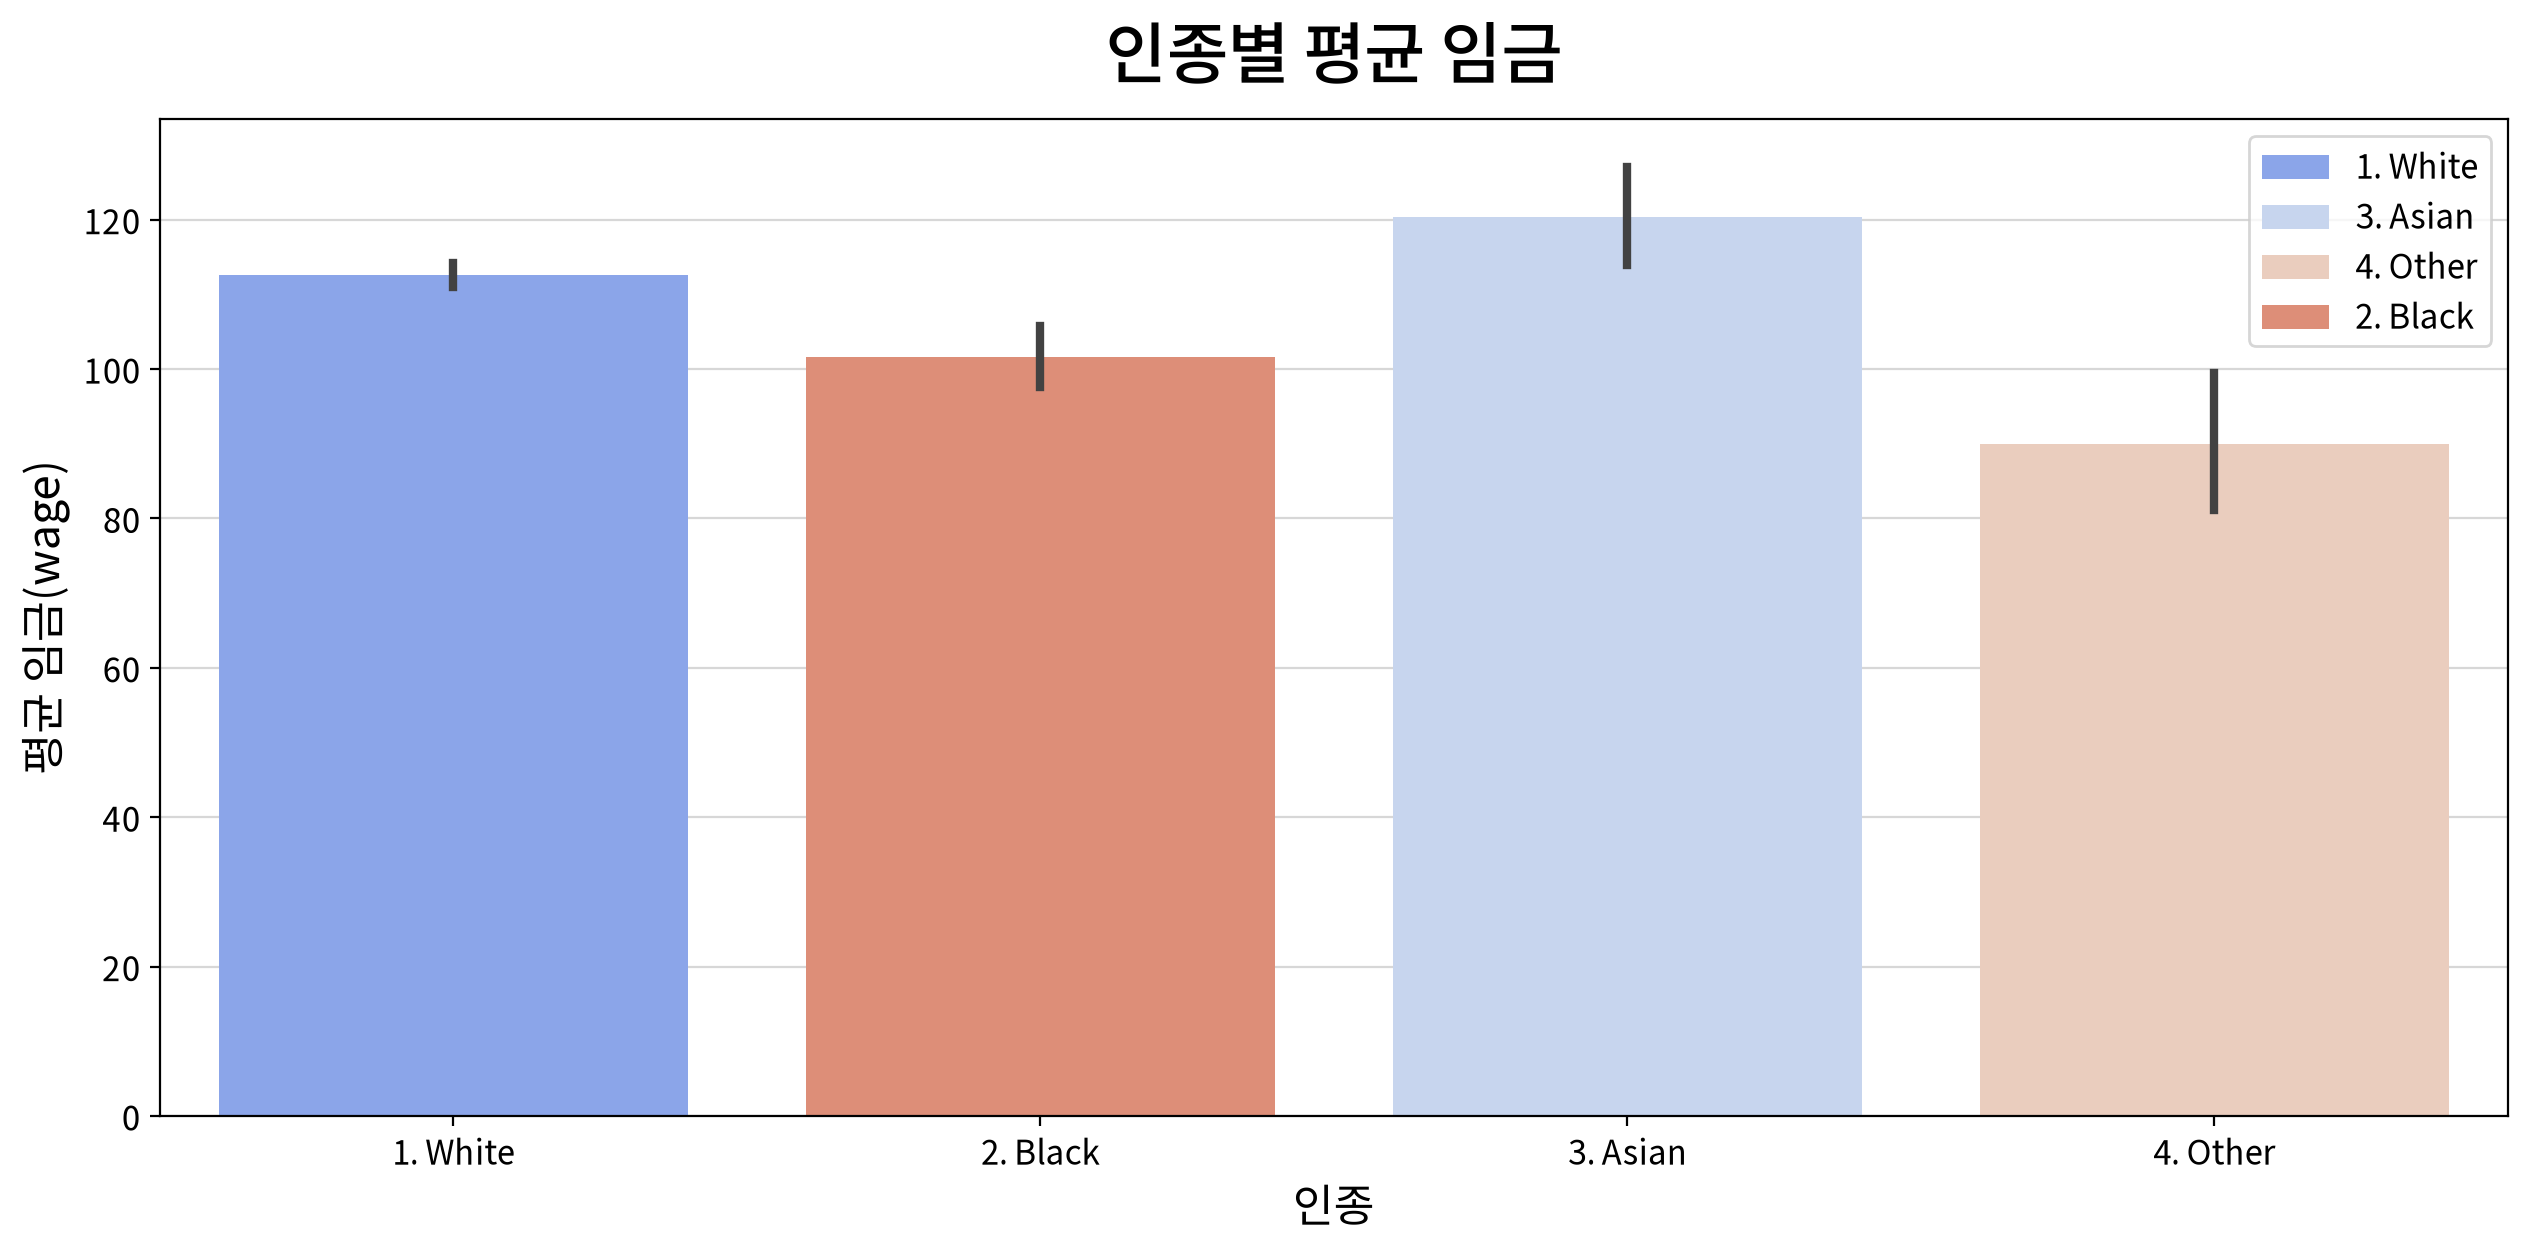

In [59]:
my_plot.barplot(origin, x="race", y="wage", estimator=np.mean,
                order=race_order, hue="race", palette="coolwarm",
                title="인종별 평균 임금", xlabel="인종", ylabel="평균 임금(wage)")

## 문제 9. 직군(`jobclass`)과 인종(`race`)을 함께 고려할 때, 사무직(Information)에서 200 이상의 고임금 비중이 특히 두드러지는 인종은?

① White  ② Black  ③ Asian  ④ Other

> 💡 **힌트**: 바이올린플롯 (x=jobclass, y=wage, hue=race)
> 🎯 **ADsP 개념**: 다변량(2범주×연속형) 분포 비교

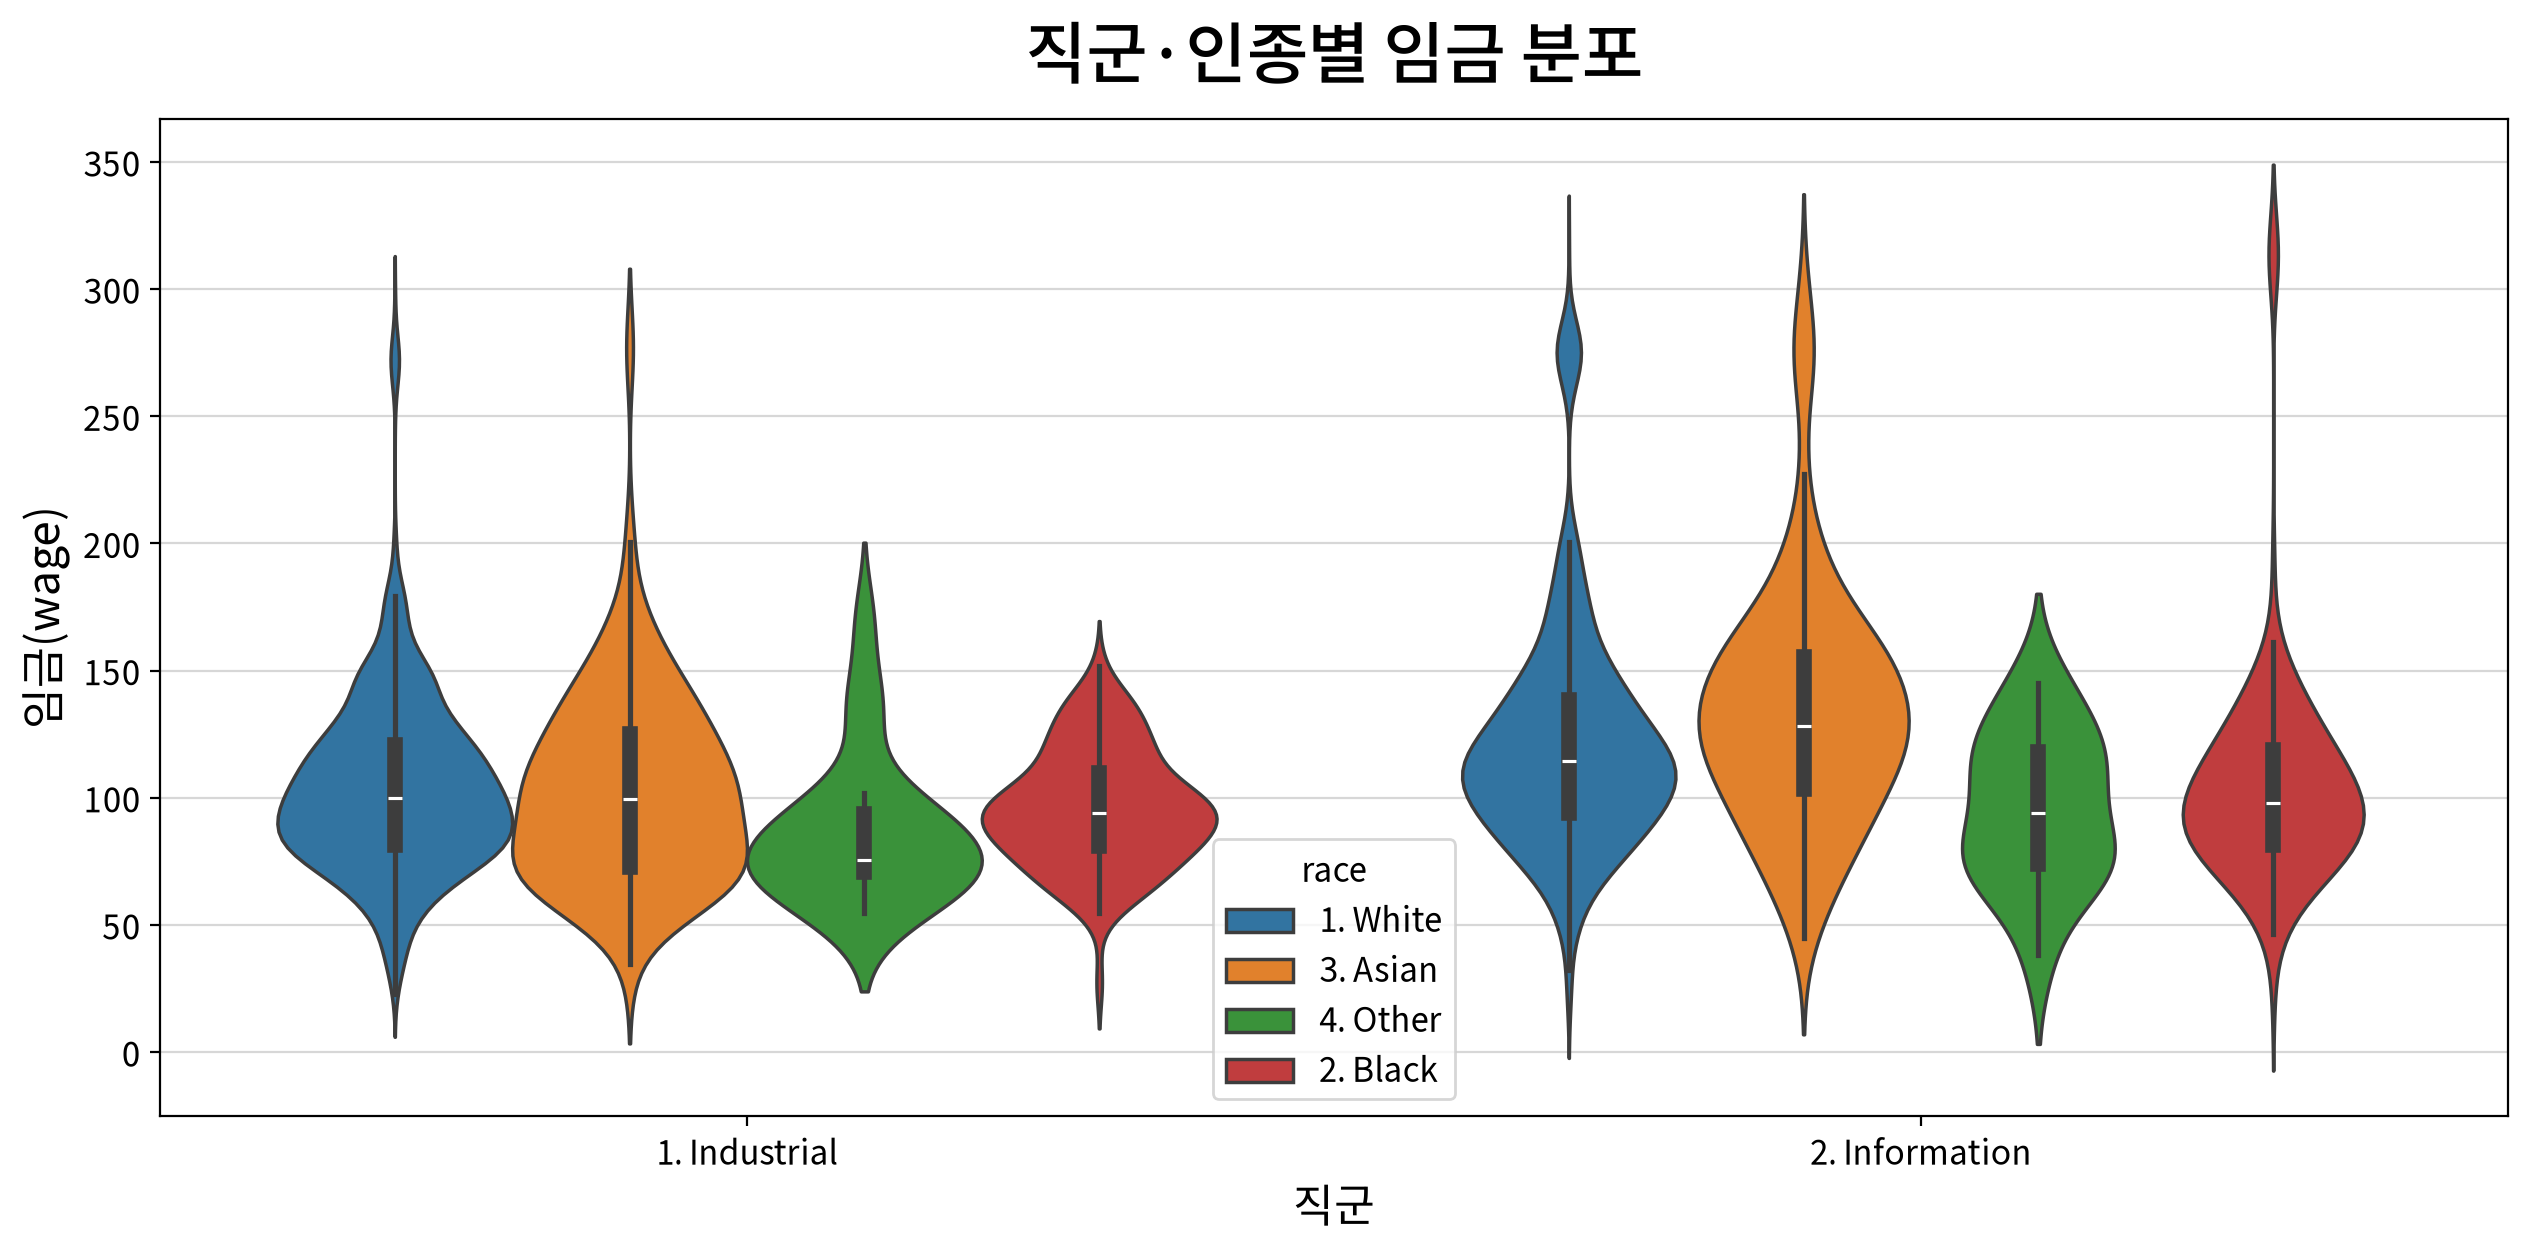

In [60]:
my_plot.violinplot(origin, x="jobclass", y="wage", hue="race",
                   title="직군·인종별 임금 분포", xlabel="직군", ylabel="임금(wage)")

## 문제 10. 나이(`age`)가 많아질수록 임금(`wage`)은 대체로 어떻게 변하는가?

① 계속 가파르게 증가한다  ② 중년까지 증가하다 이후 정체·감소하는 경향  ③ 계속 감소한다  ④ 아무런 경향이 없다

> 💡 **힌트**: 산점도 + 추세선(lmplot)
> 🎯 **ADsP 개념**: 산점도·추세선 해석 · 비선형 추세

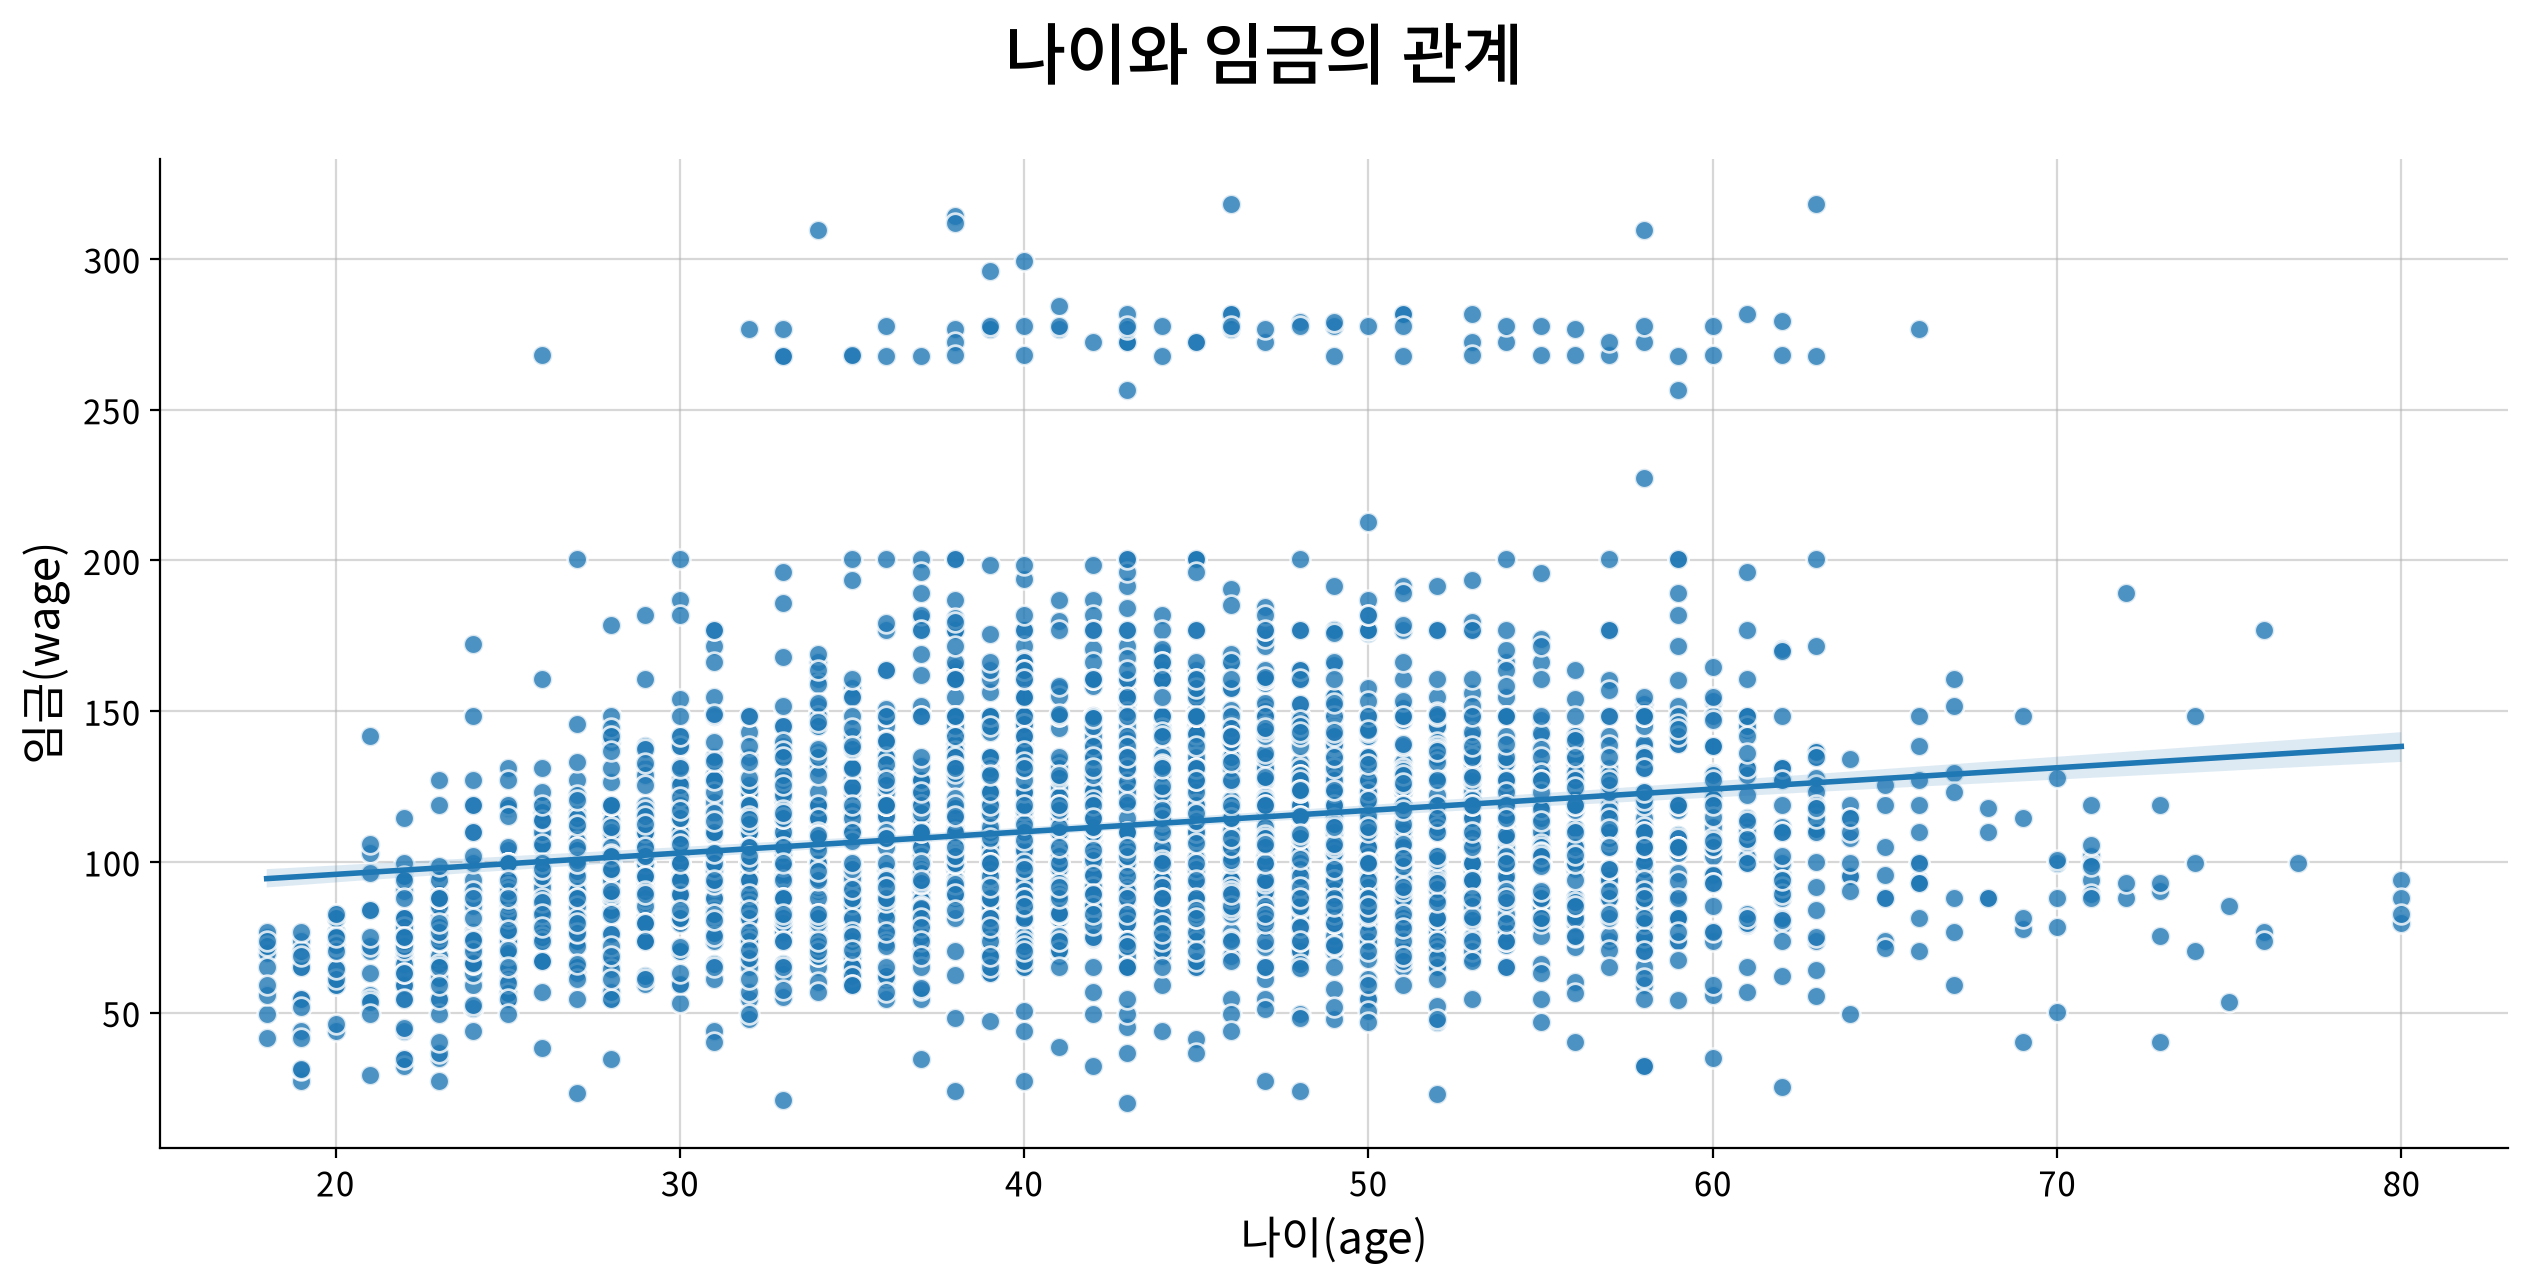

In [61]:
my_plot.lmplot(origin, x="age", y="wage",
               title="나이와 임금의 관계", xlabel="나이(age)", ylabel="임금(wage)")

## 문제 11. 연령대별 평균 임금이 가장 높은 구간은?

① 20대 이하  ② 30대  ③ 40대  ④ 60대 이상

> 💡 **힌트**: 산점도(lmplot) 또는 연령대 구간화 후 막대그래프
> 🎯 **ADsP 개념**: 연속형 변수의 구간화(binning) · 비선형 추세

In [62]:
df = origin.copy()
df["age_bin"] = pd.cut(df["age"], bins=[17, 30, 40, 50, 60, 80],
                      labels=["30대 이하", "30대", "40대", "50대", "60대 이상"])
df.groupby("age_bin", observed=True)["wage"].mean()

age_bin
30대 이하    89.537
30대      113.333
40대      118.586
50대      118.179
60대 이상   112.764
Name: wage, dtype: float64

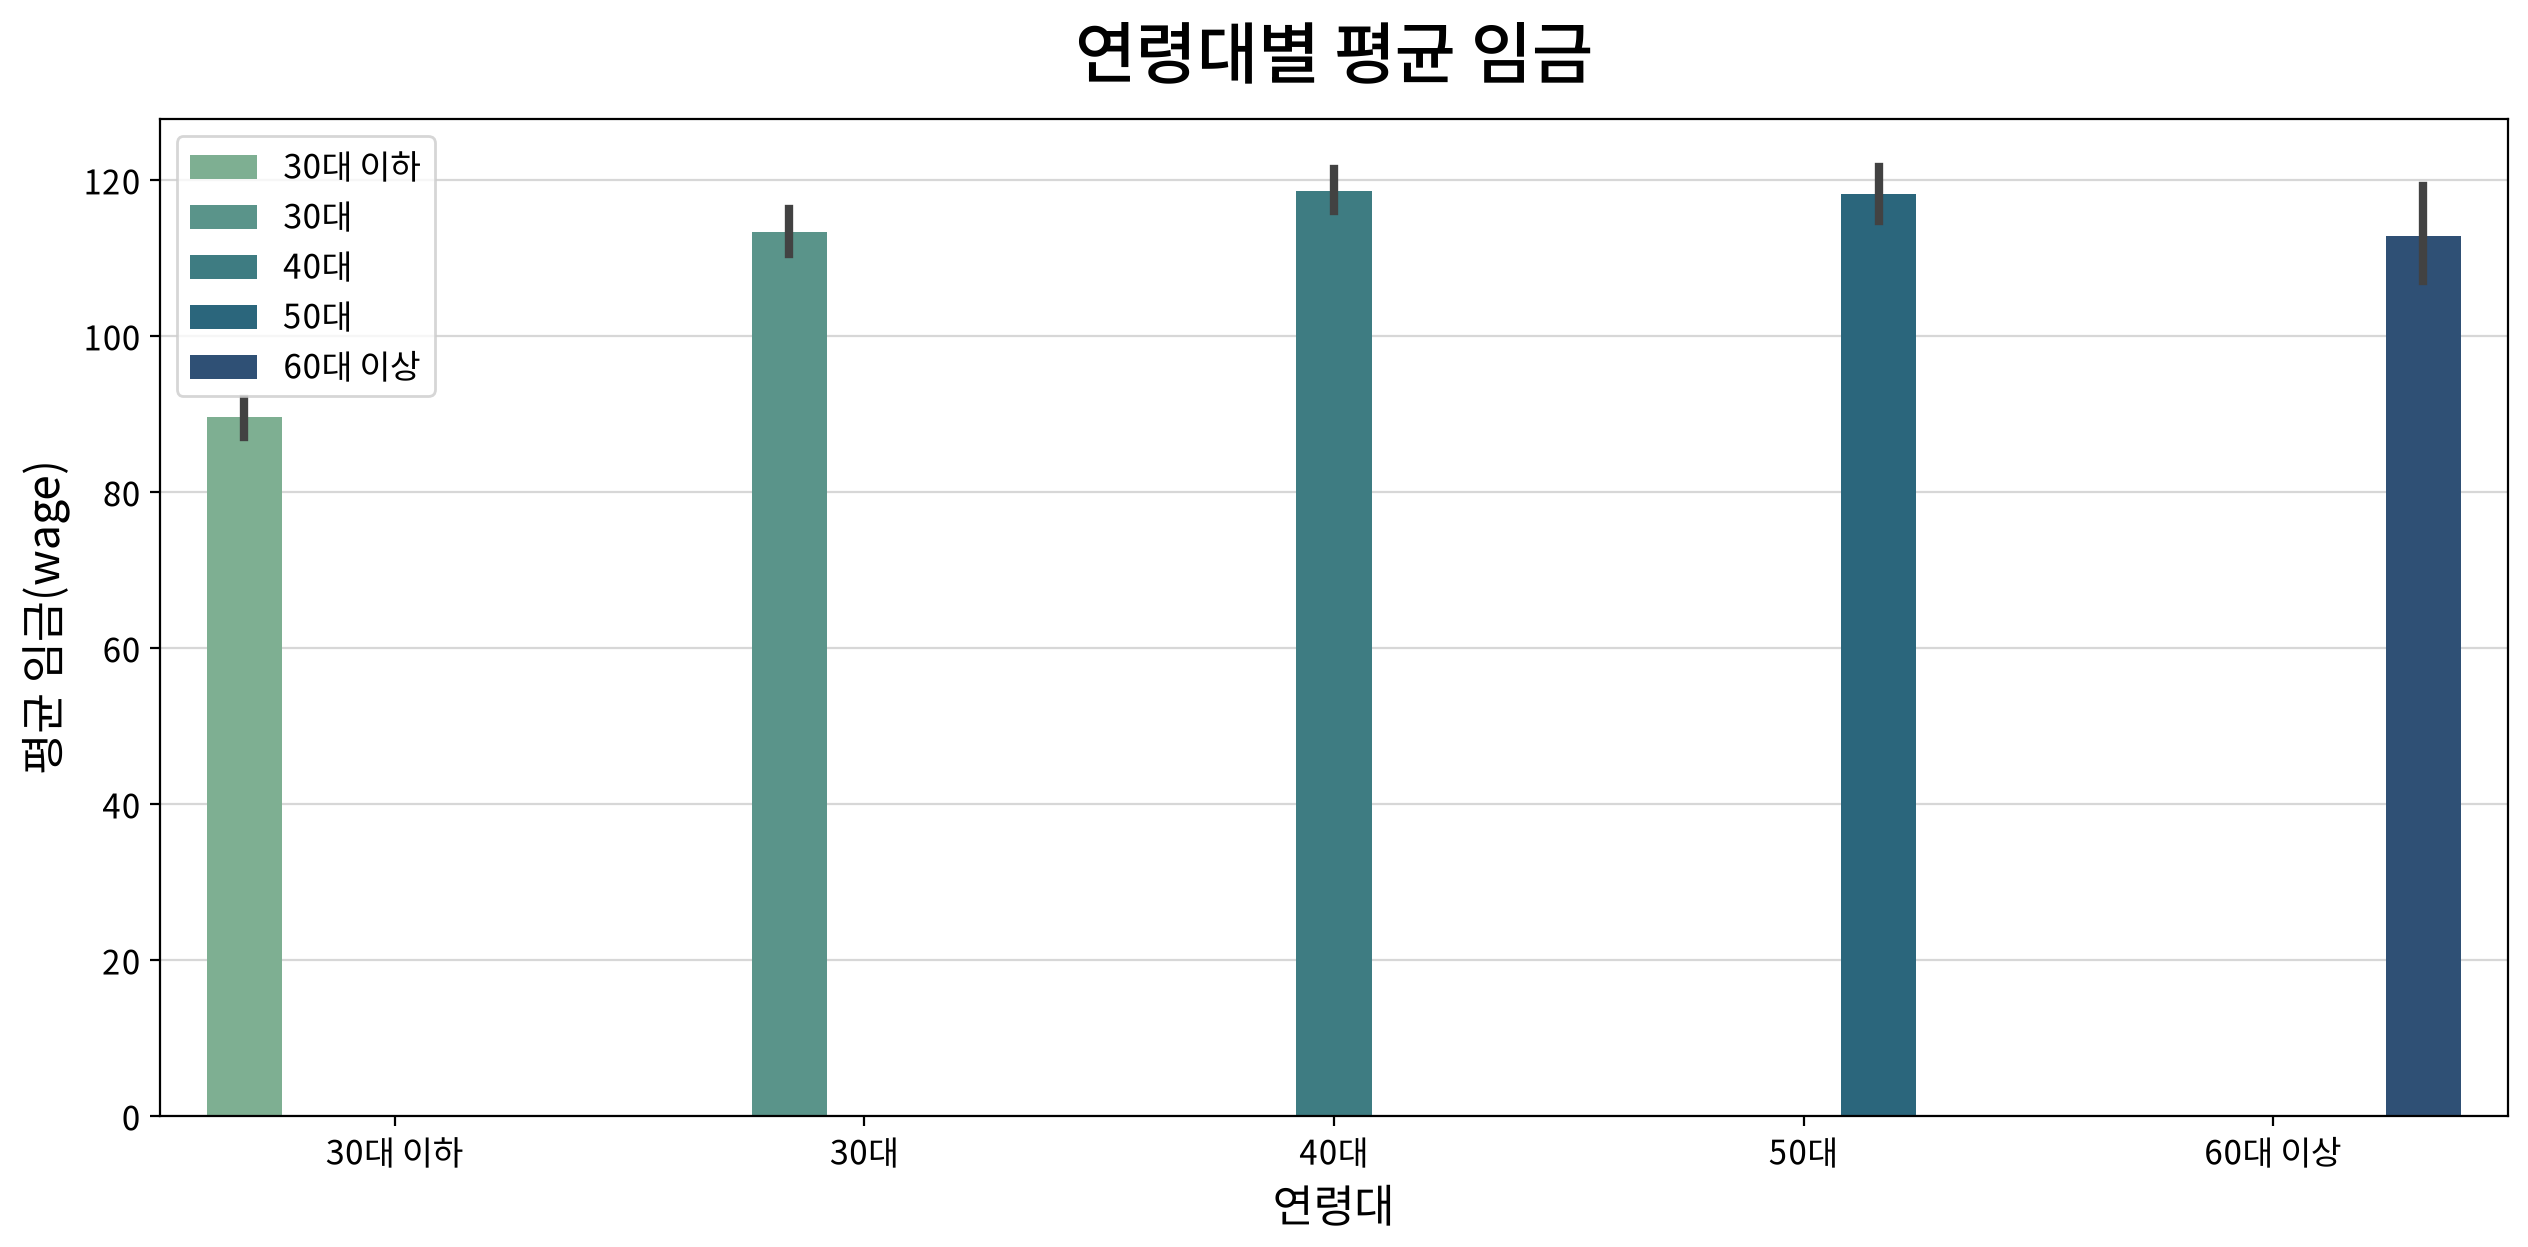

In [63]:
my_plot.barplot(df, x="age_bin", y="wage", estimator=np.mean,
                hue="age_bin", palette="crest",
                title="연령대별 평균 임금", xlabel="연령대", ylabel="평균 임금(wage)")

## 문제 12. 연도(`year`)별 임금 추이를 교육 수준(`education`)별로 나누어 볼 때, 임금이 가장 높고 변동(상승 후 2009년 하락)이 가장 두드러진 집단은?

① < HS Grad  ② HS Grad  ③ College Grad  ④ Advanced Degree

> 💡 **힌트**: 선그래프(lineplot, x=year, y=wage, hue=education)
> 🎯 **ADsP 개념**: 시계열 추세 · 집단별 추이 비교

In [64]:
df = origin.copy()
df["education"] = pd.Categorical(df["education"],
                                 categories=sorted(df["education"].unique()), ordered=True)

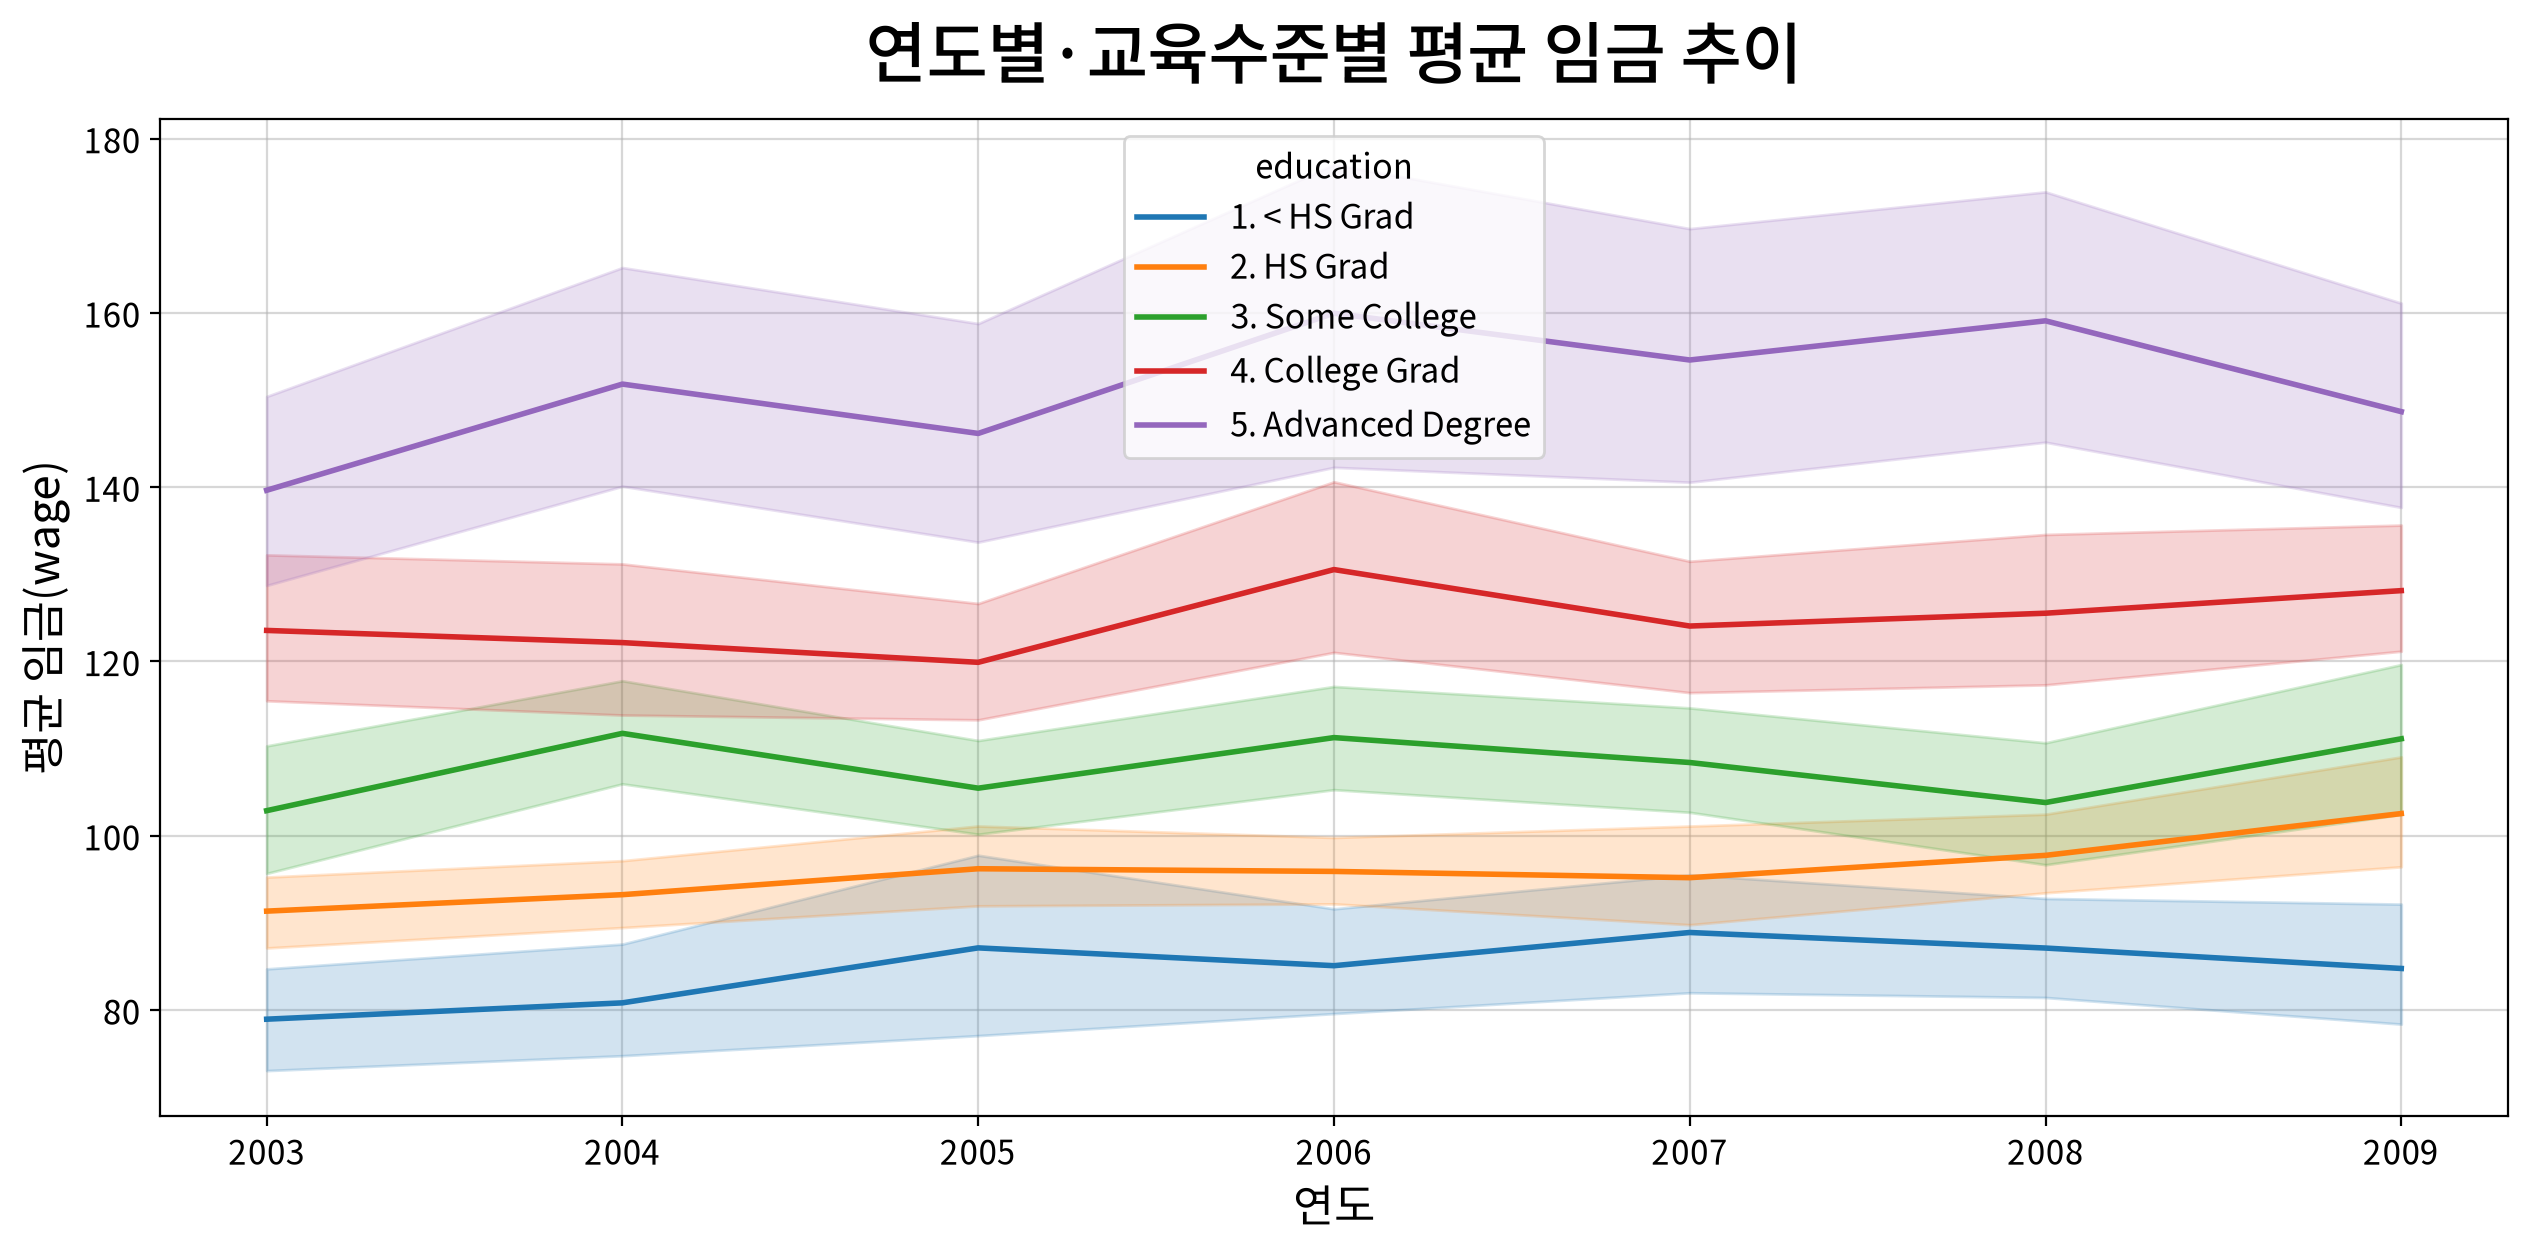

In [65]:
my_plot.lineplot(df, x="year", y="wage", hue="education",
                 title="연도별·교육수준별 평균 임금 추이", xlabel="연도", ylabel="평균 임금(wage)")

## 문제 13. 직군(`jobclass`)별 건강상태(`health`)를 비교할 때, 평균 이하(≤Good) 건강상태 비중이 더 높은 직군은?

① 생산직(Industrial)  ② 사무직(Information)  ③ 동일하다  ④ 사무직에만 나타난다

> 💡 **힌트**: 막대그래프(countplot, x=jobclass, hue=health) 또는 누적막대그래프
> 🎯 **ADsP 개념**: 교차분석(분할표) · 범주×범주 관계

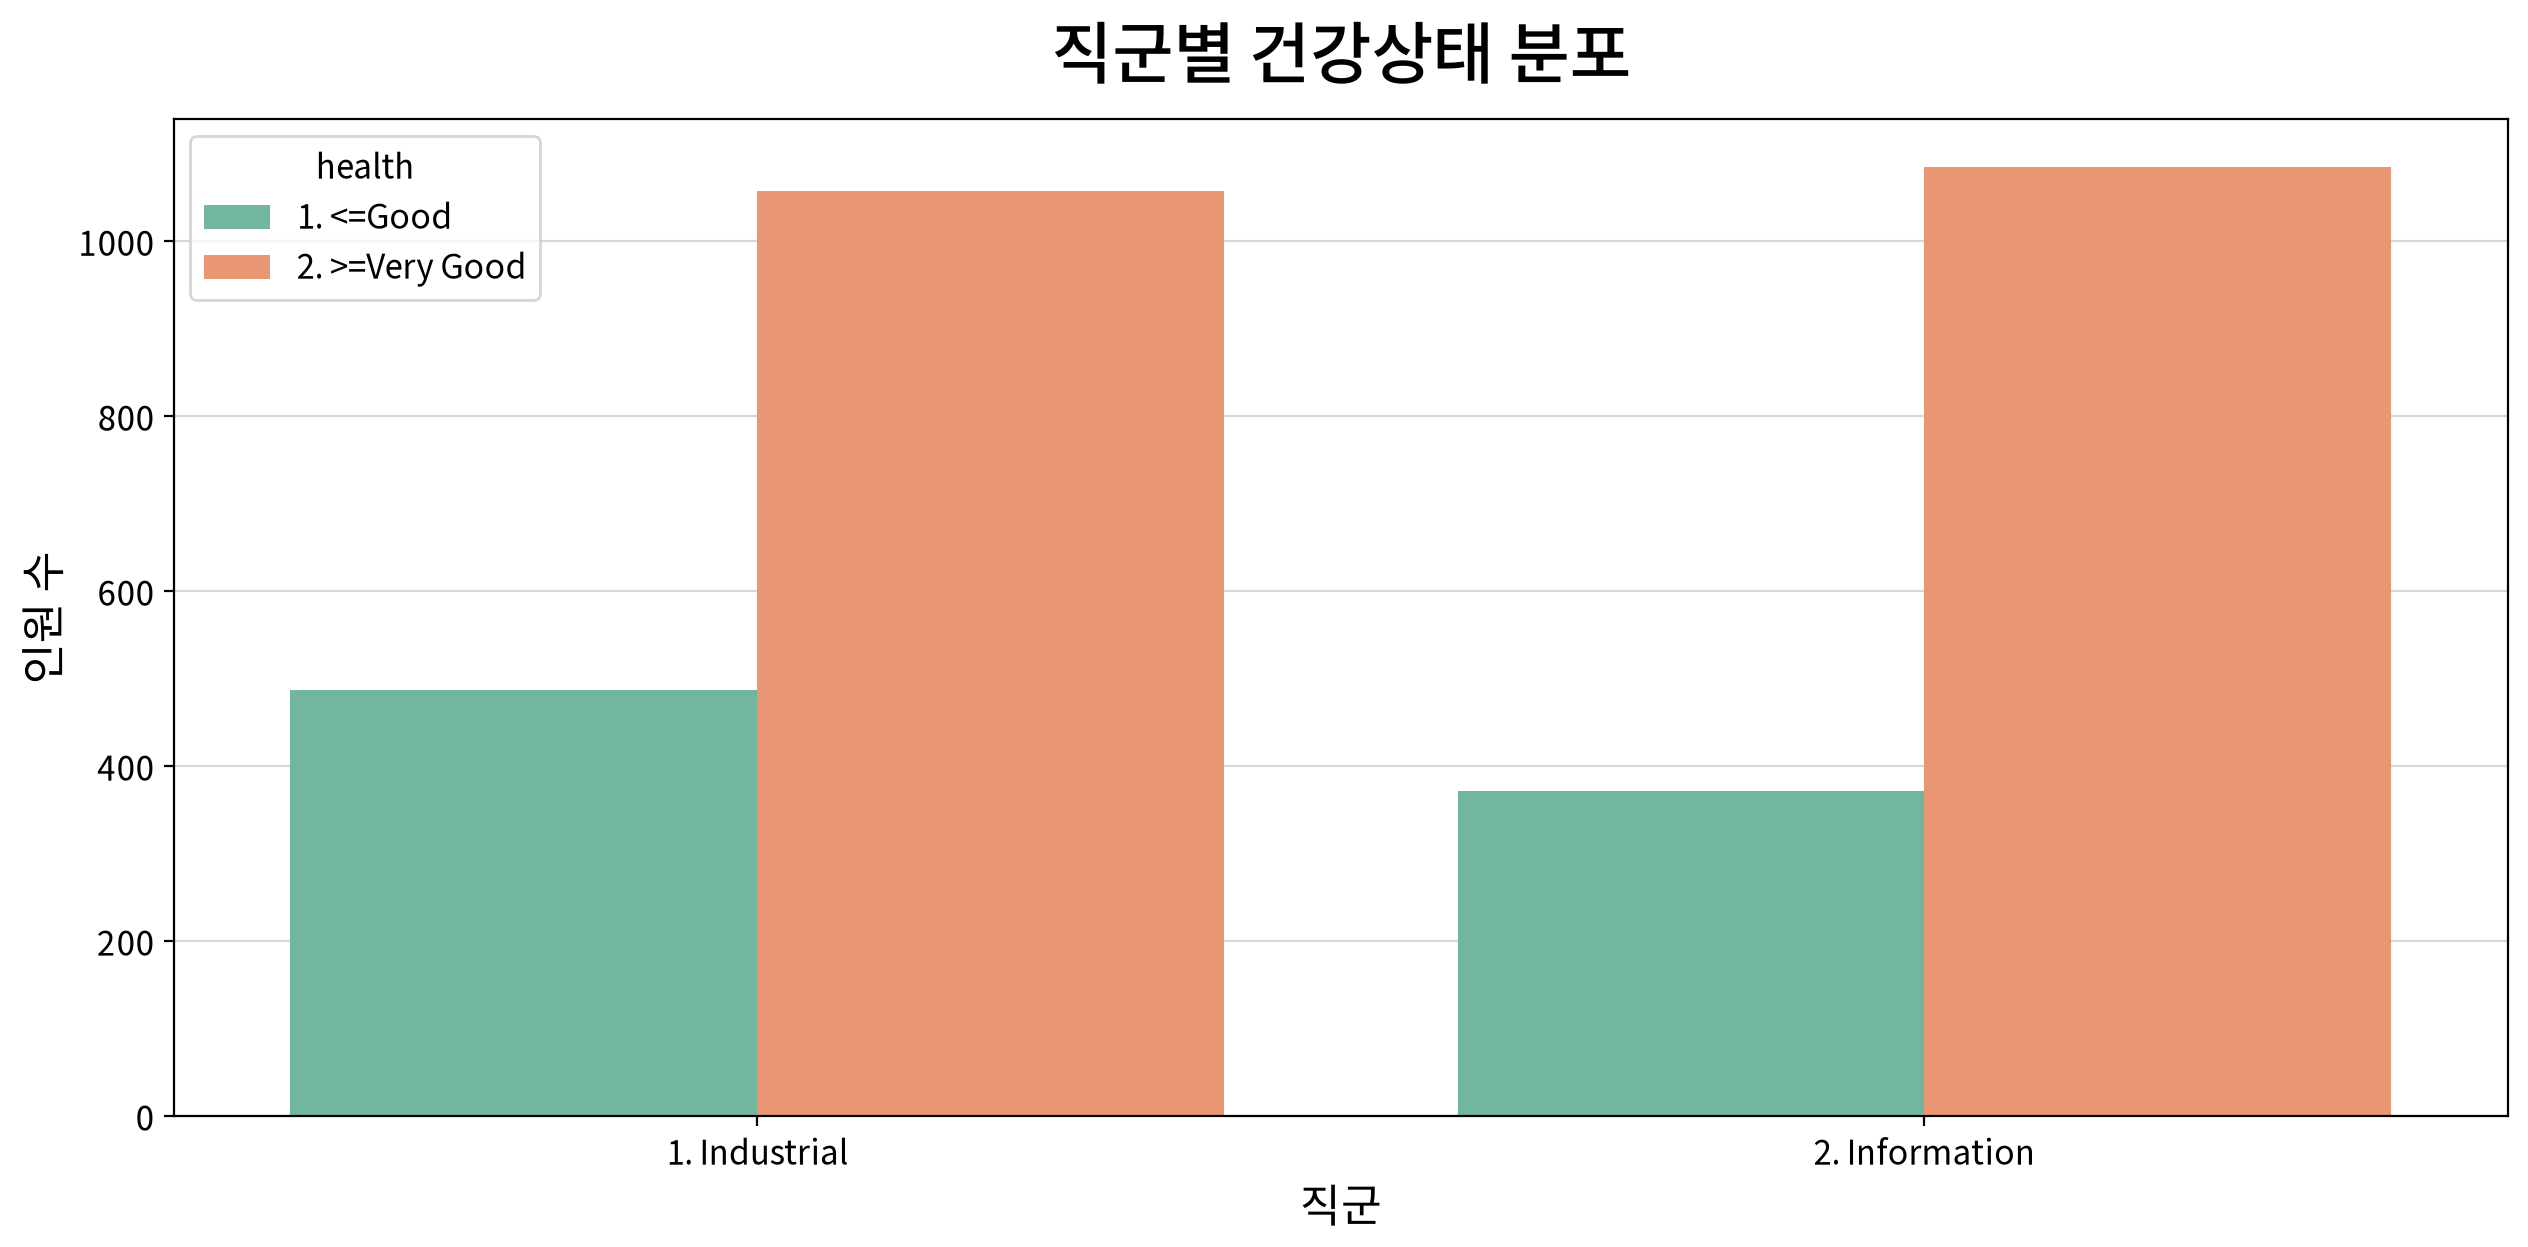

In [66]:
my_plot.countplot(origin, x="jobclass", hue="health", palette="Set2",
                  title="직군별 건강상태 분포", xlabel="직군", ylabel="인원 수")

## 문제 14. 고임금자(`wage` 250 초과)는 어느 직군에 더 많이 분포하는가?

① 생산직(Industrial)  ② 사무직(Information)  ③ 동일하다  ④ 생산직에만 있다

> 💡 **힌트**: 막대그래프(countplot, wage>250 필터 후 jobclass) 또는 누적막대그래프
> 🎯 **ADsP 개념**: 조건부 필터링 · 교차 빈도 분석

In [67]:
high = origin[origin["wage"] > 250]
high["jobclass"].value_counts()

jobclass
2. Information    61
1. Industrial     18
Name: count, dtype: int64

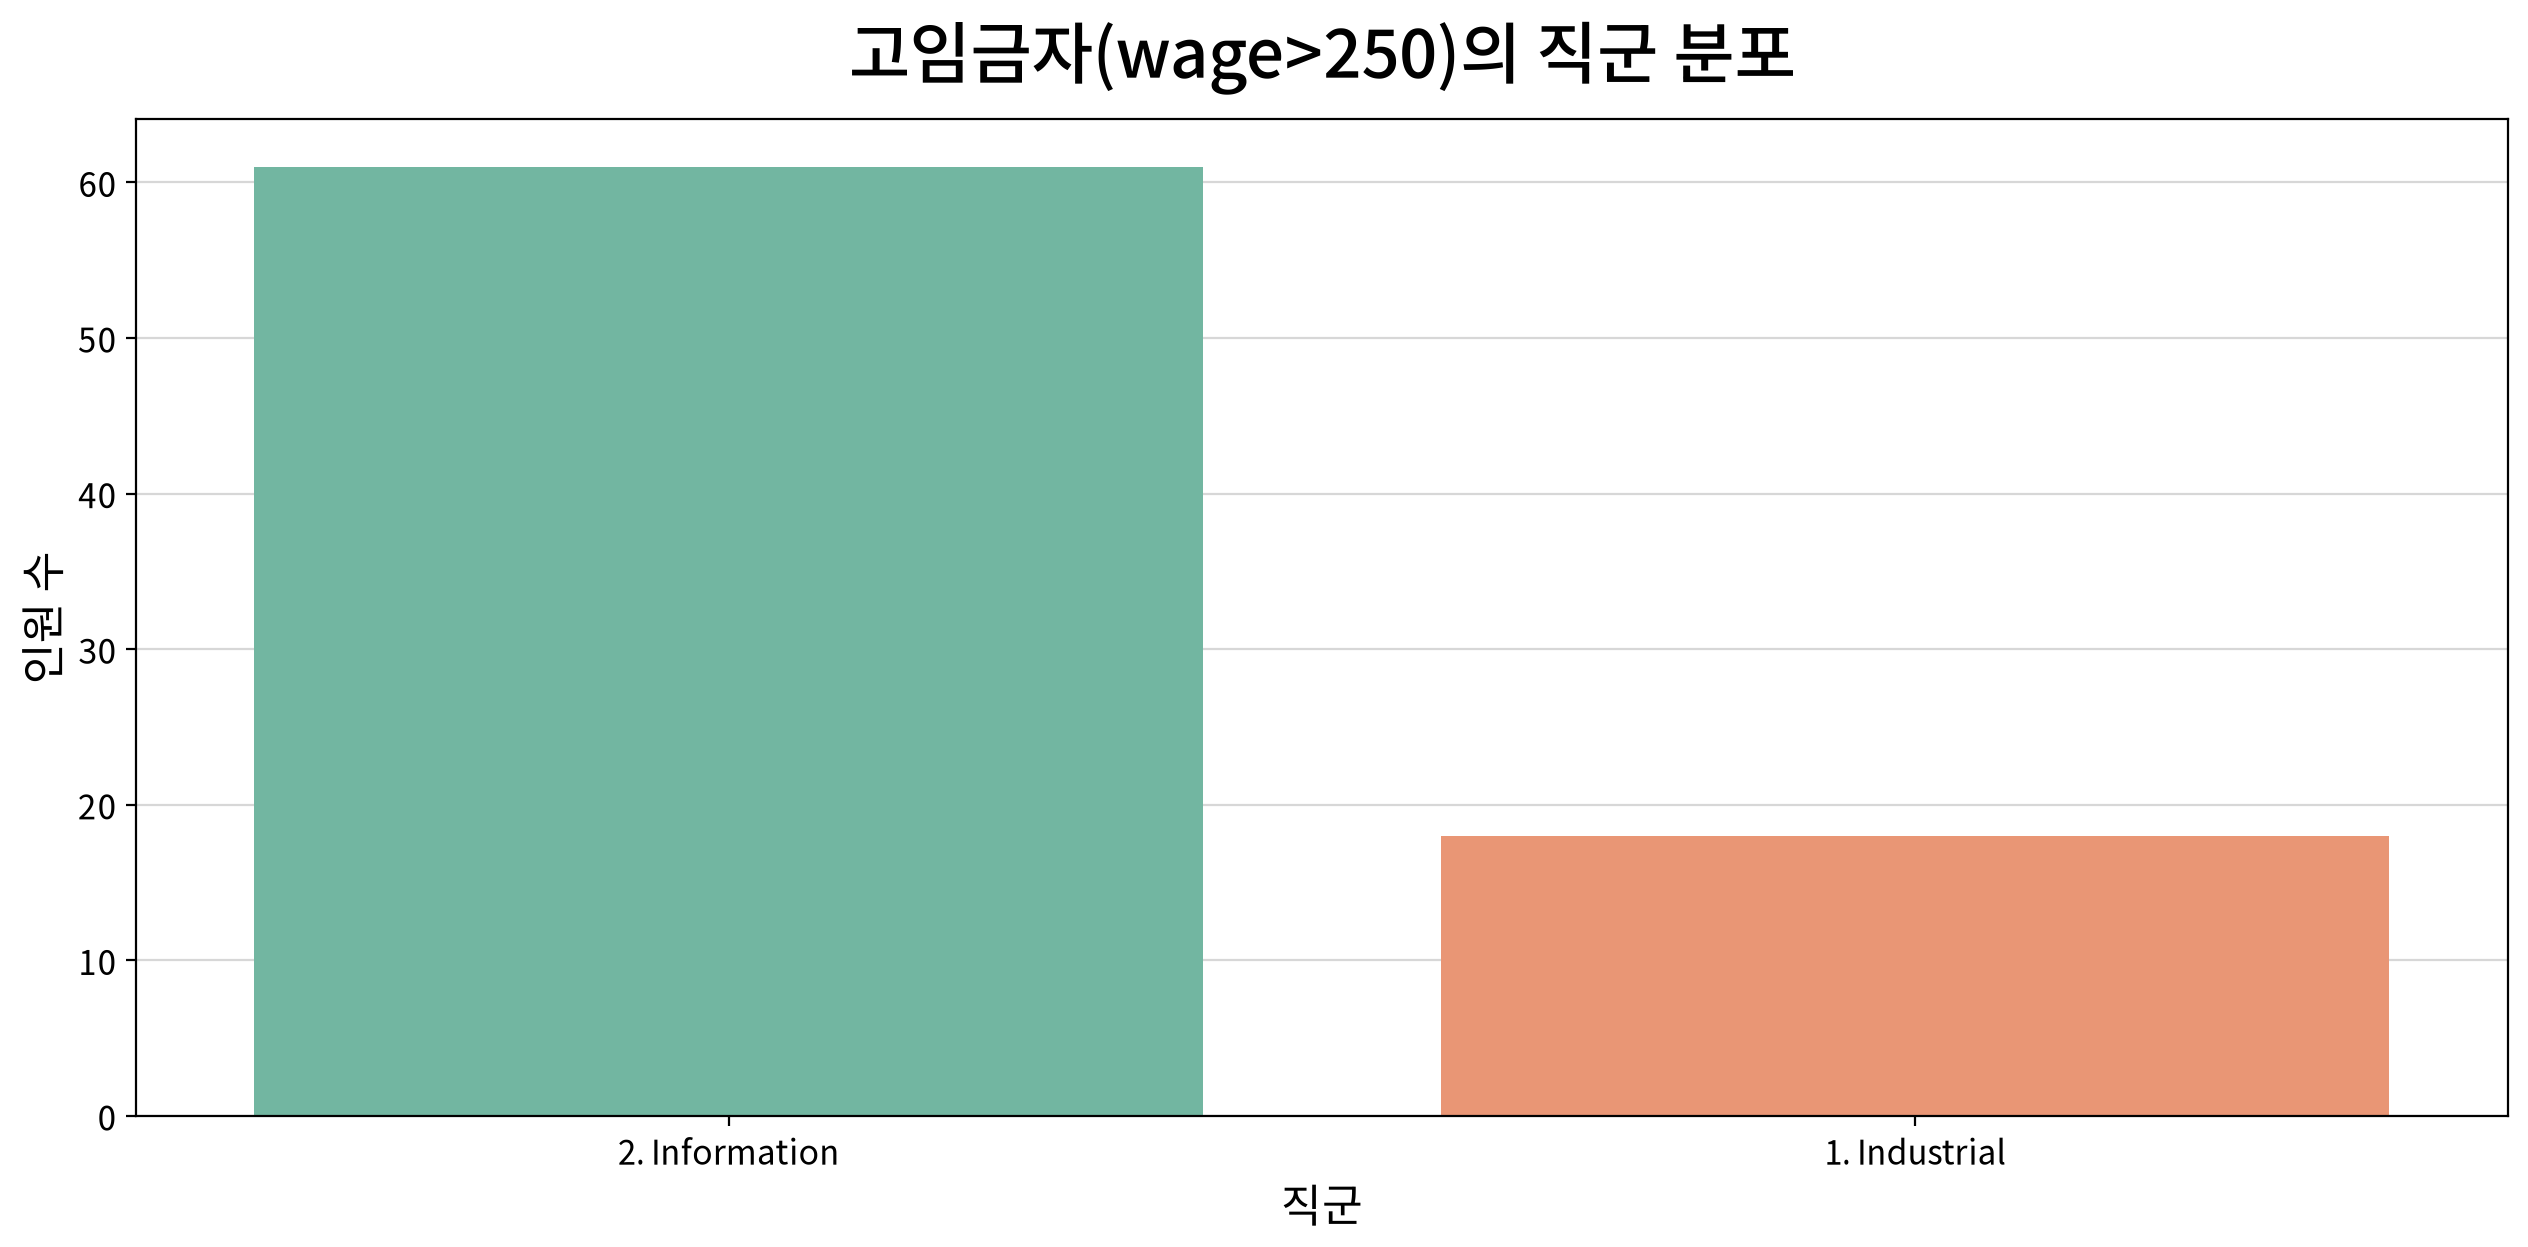

In [68]:
my_plot.countplot(high, x="jobclass", hue="jobclass", palette="Set2",
                  title="고임금자(wage>250)의 직군 분포", xlabel="직군", ylabel="인원 수")

## 문제 15. 나이(`age`)와 임금(`wage`)을 각각 박스플롯으로 그렸을 때, 데이터가 더 넓은 범위에 퍼져(산포가 큰) 있는 변수는?

① age  ② wage  ③ 두 변수의 퍼짐이 동일하다  ④ 판단할 수 없다

> 💡 **힌트**: 박스플롯 (두 변수를 개별적으로)
> 🎯 **ADsP 개념**: 산포(범위 · 사분위 범위(IQR) · 표준편차)

In [69]:
origin[["age", "wage"]].describe()

,age,wage
count,3000.000,3000.000
mean,42.415,111.704
std,11.542,41.729
min,18.000,20.086
25%,33.750,85.384
50%,42.000,104.922
75%,51.000,128.680
max,80.000,318.342


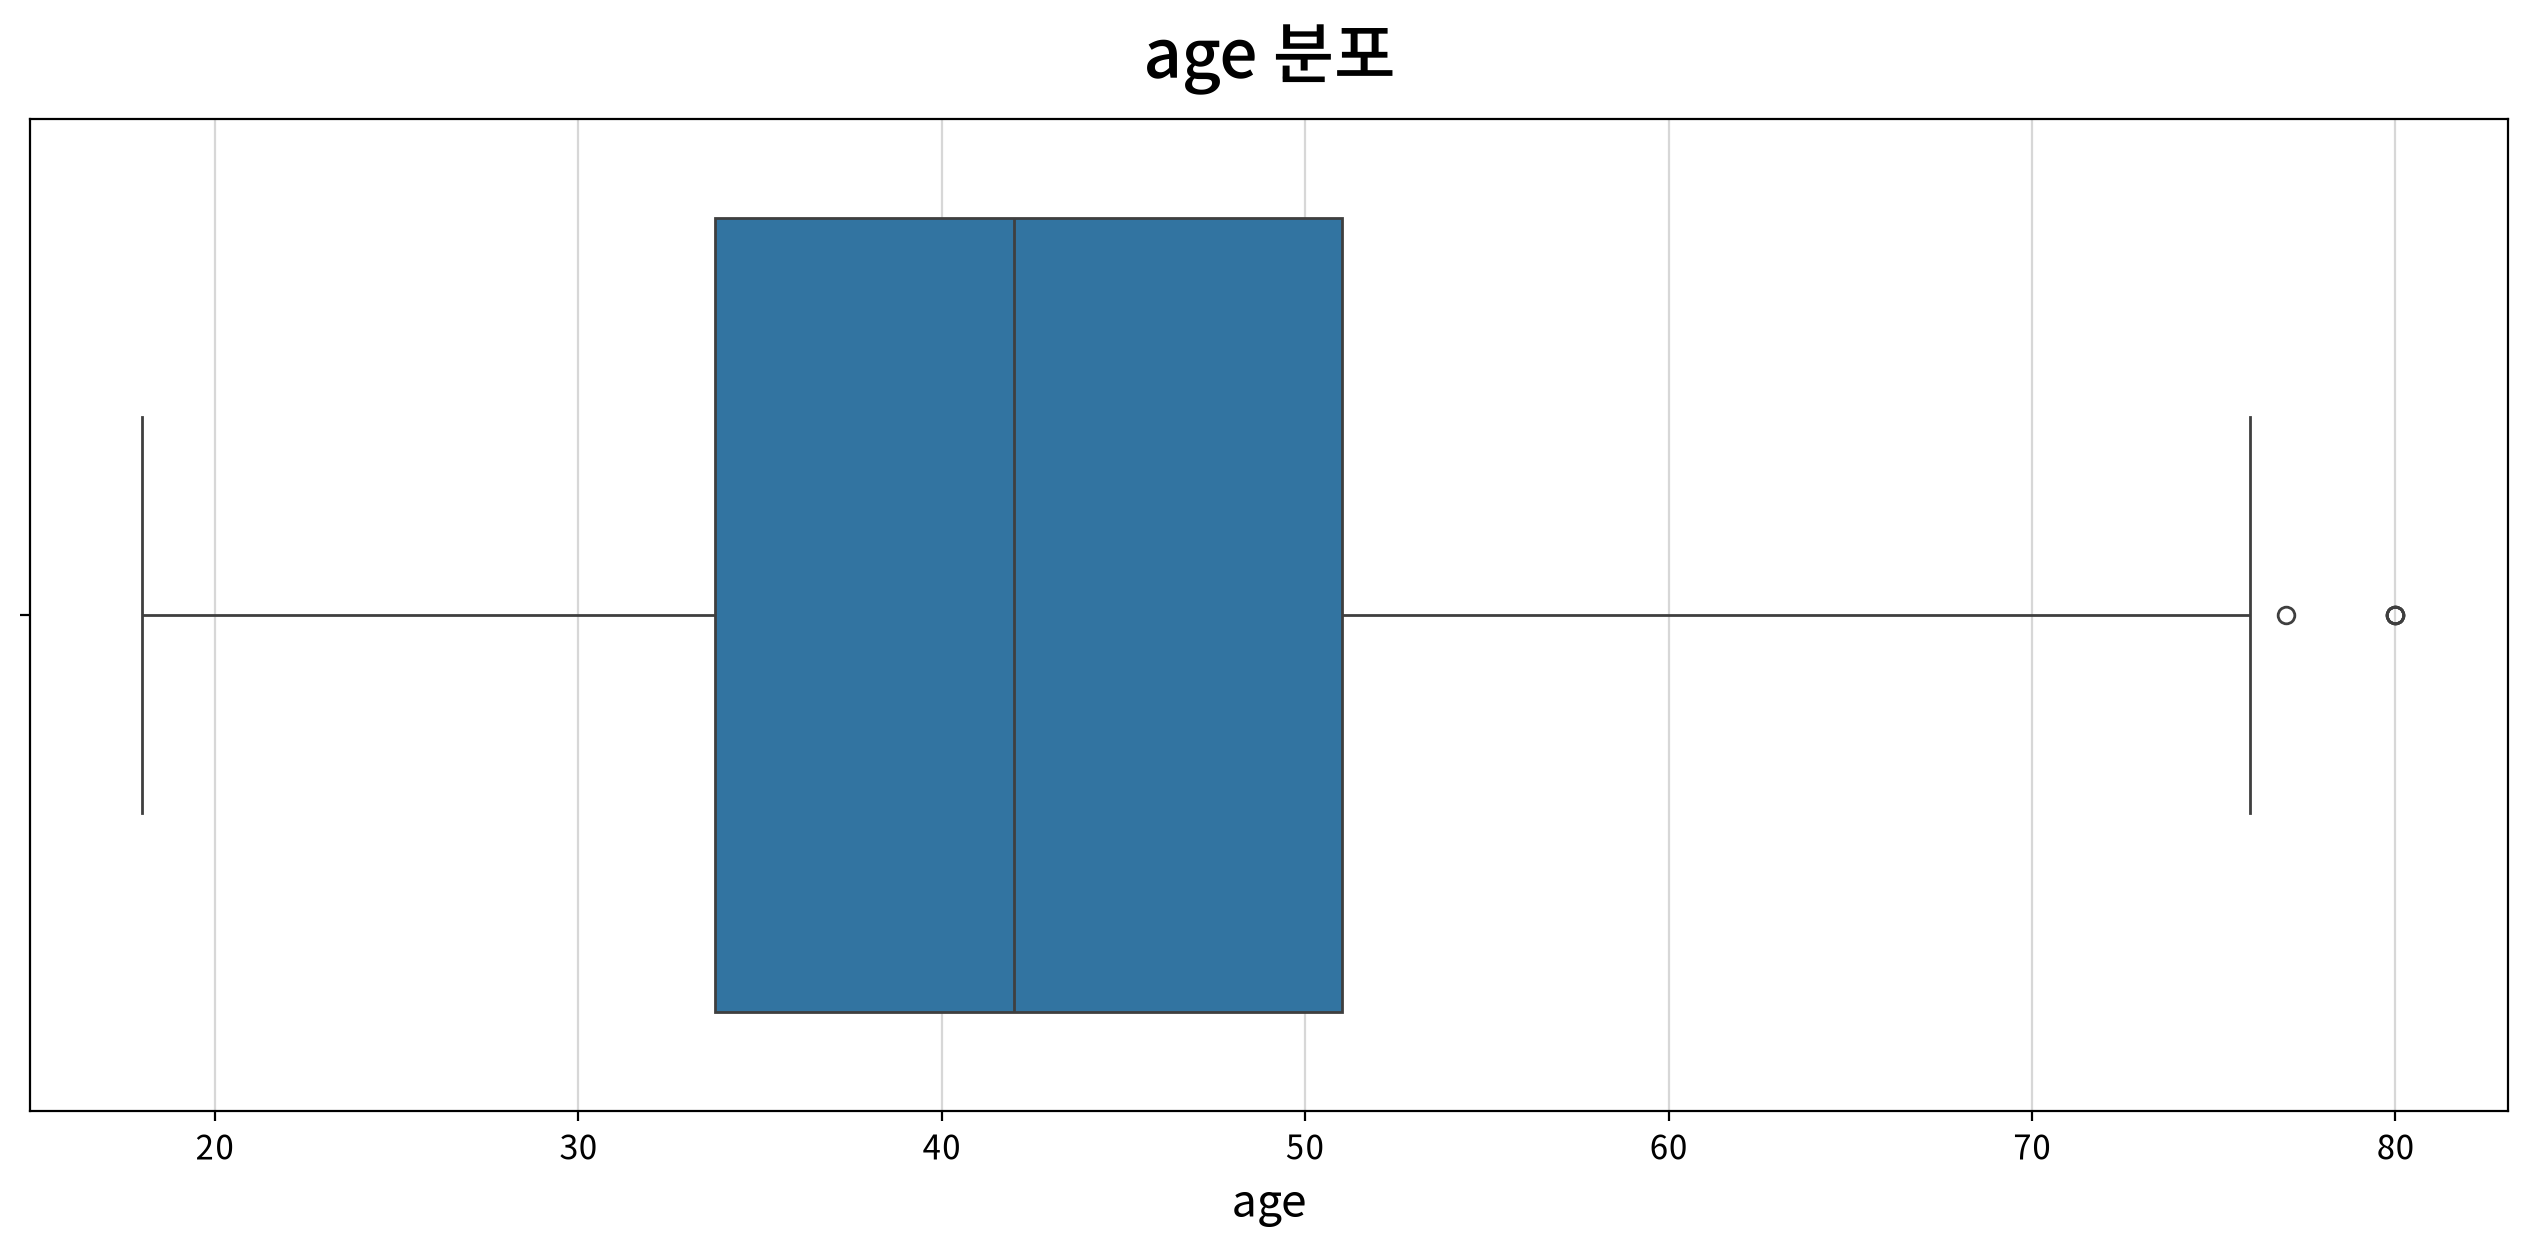

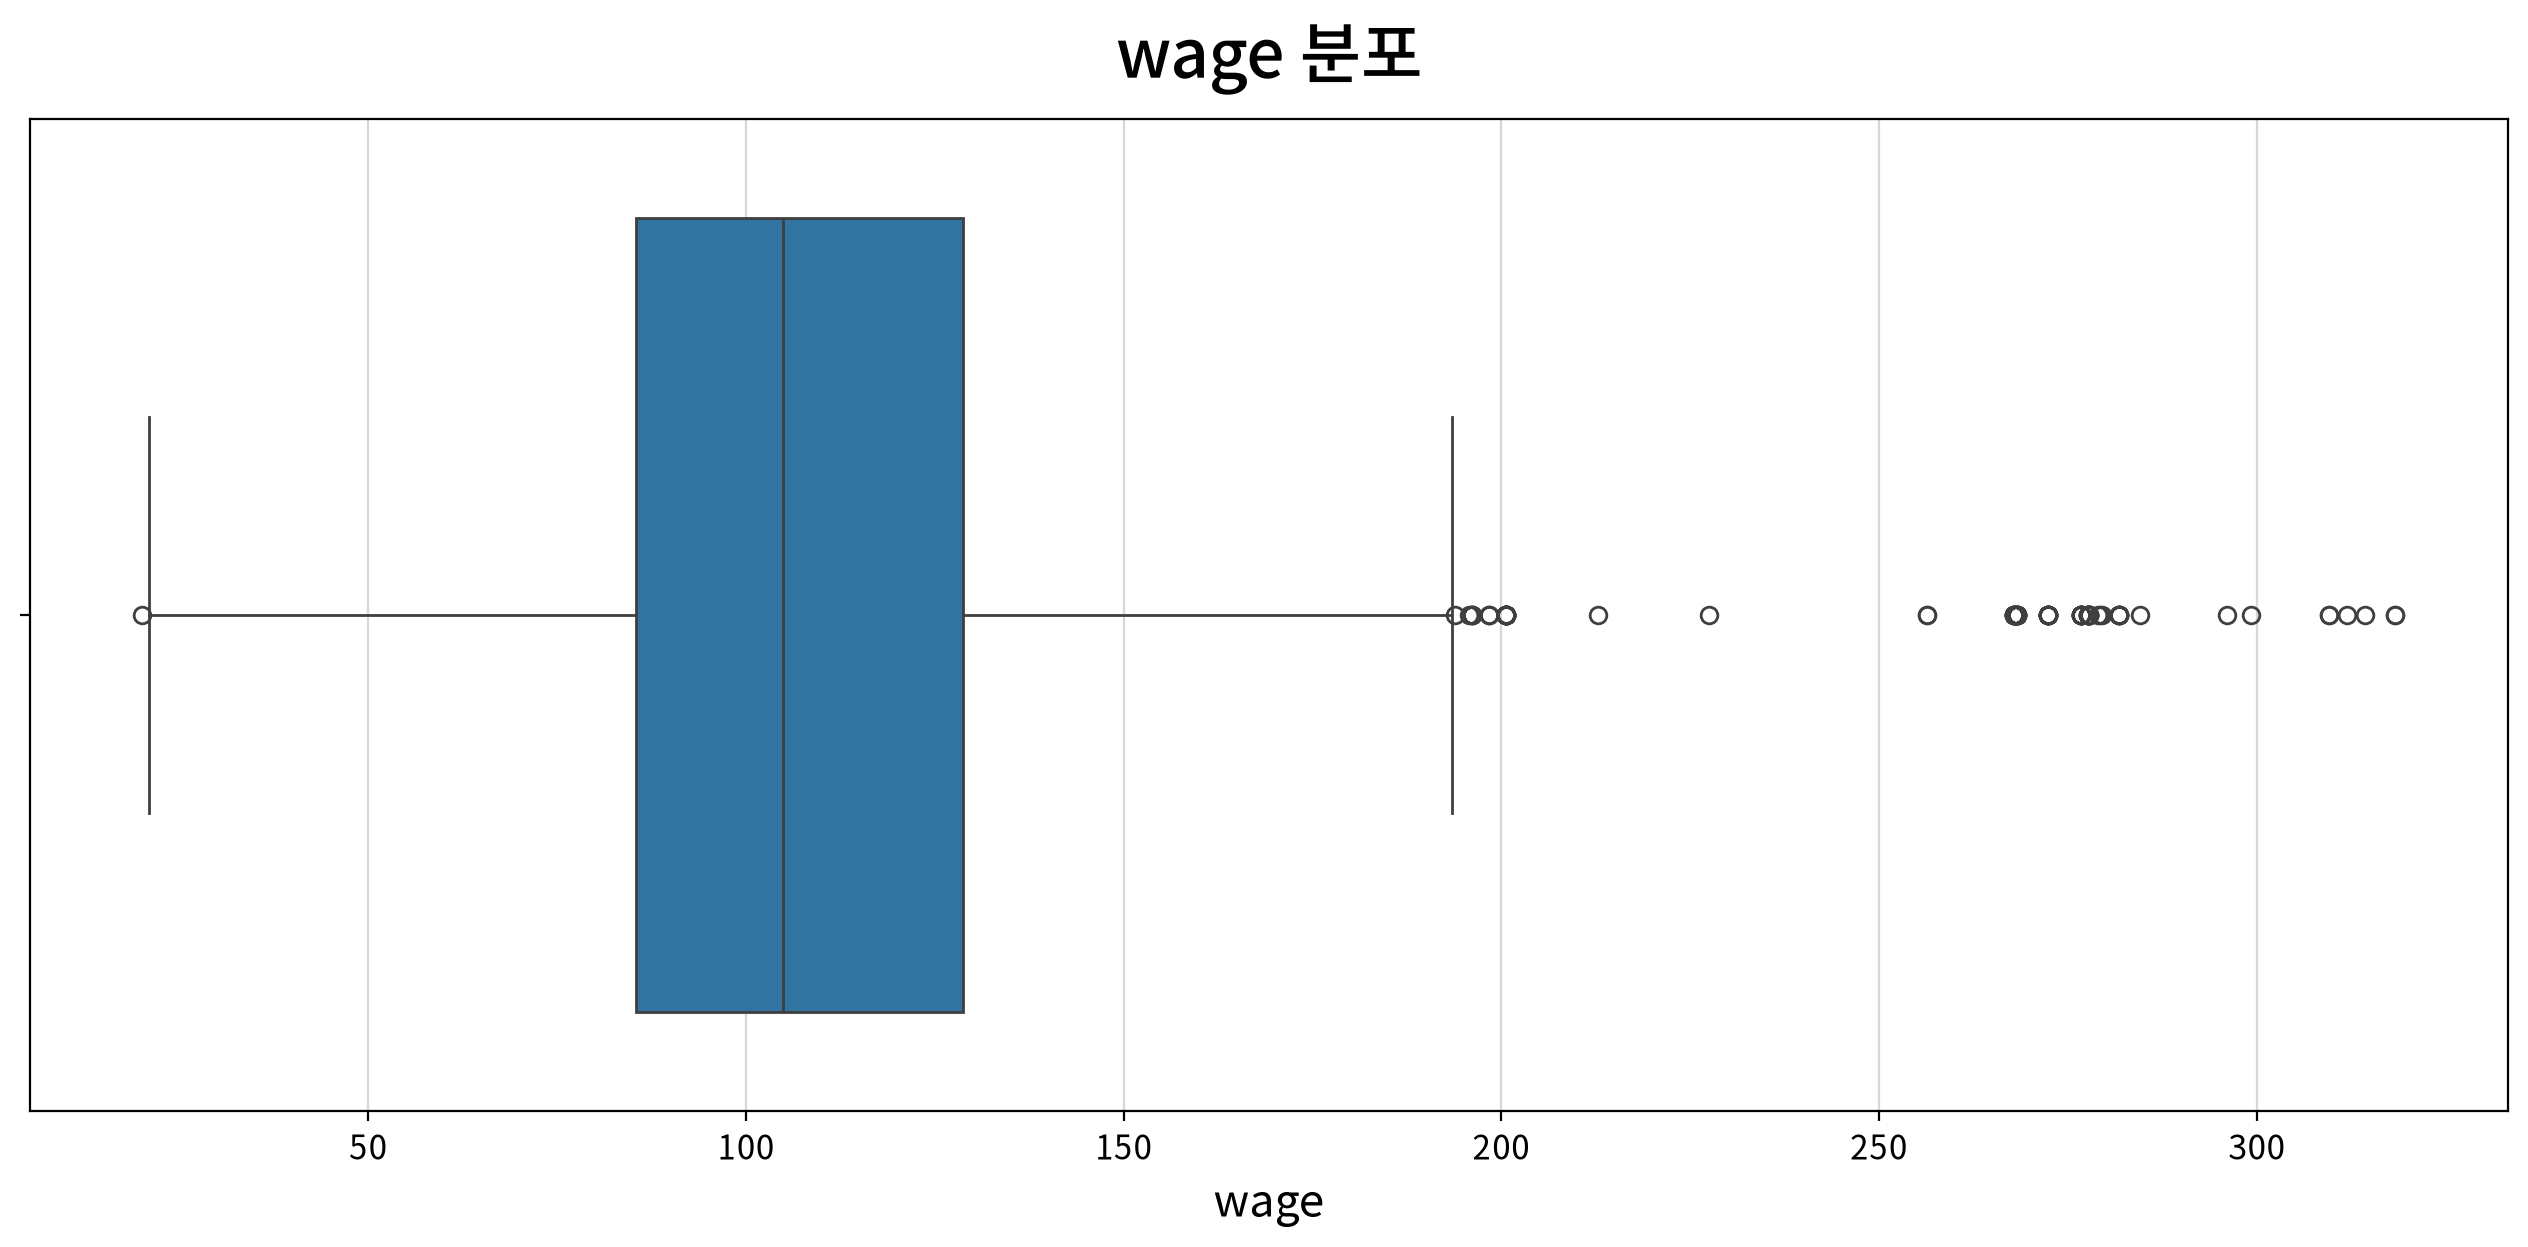

In [70]:
for c in ["age", "wage"]:
    my_plot.boxplot(origin, x=c, title=f"{c} 분포", xlabel=c)